# Lab 2 - Model Agnostic Methods

**How the lab works**

**Authors:** Ariful Islam Riane (3981886) and Pedro Fernandez Tonso (3983781) - **Group number:** 19

- The questions are divided into three levels.
  - **[Basic]**: if your group completes all Basic questions of a lab correctly, you get a 6 (a passing grade).
  - **[Regular]**: these questions give up to 2 extra points.
  - **[Advanced]**: for students looking for a challenge; expect to work on them in your own time.
- Every group works with slightly different data and settings, so your answers, numbers and plots are different from those of other groups.
  - Set your group number $G$ in the first code cell. Your seed is $S = G$; use it everywhere a random seed is needed (`random_state=S`).
  - *Your patient* is row $p = S \bmod n$ of your test set, where $n$ is the number of rows in the test set.
  - Put your group number in the title of every plot.
- Answers must use the numbers and plots from your own notebook. An answer that does not match your own output gets no points.
- You may use AI tools to help with code, but every group member must be able to explain what you hand in.
- Lines marked `# TODO` must be completed. Write your answers in the **Your answers** cells.
- Hand in this notebook with all cells run. Also convert the notebook with all cells run into PDF and hand in. 
  

**Data and models.** Use the same group number, data, split and models as in Lab 1, plus a random forest.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xai_lab_utils import group_seed, personal_data_path, your_patient_index

In [2]:
# Fill in your group number. Everything else depends on it.
GROUP_NUMBER = 19  # TODO: your group number, e.g. 7

S = group_seed(GROUP_NUMBER)   # use S everywhere a random seed is needed
print("Group", GROUP_NUMBER, "- seed S =", S)

Group 19 - seed S = 19


In [3]:
# Code from Lab 1: reading the data file (Q1)
path = personal_data_path(GROUP_NUMBER)
df = pd.read_csv(path, sep=",", header=0, decimal=".")

# the train/test split and the preprocessor (Q3)
X = df.drop(columns="target").astype(float)   # float: needed for PDP in recent scikit-learn
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=S)

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]   # numerical attributes: will be scaled
cat_cols = ["cp", "restecg", "slope", "thal"]                        # categorical attributes: will be one-hot encoded
bin_cols = ["sex", "fbs", "exang"]                                   # binary attributes: kept as they are

preprocessor = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

# the three fitted models: logreg, tree, knn
logreg = make_pipeline(clone(preprocessor), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
tree = DecisionTreeClassifier(random_state=S).fit(X_train, y_train)            # a tree needs no scaling
knn = make_pipeline(clone(preprocessor), KNeighborsClassifier(n_neighbors=5)).fit(X_train, y_train)

print(df.shape, "- train:", X_train.shape, "- test:", X_test.shape)

(273, 14) - train: (204, 13) - test: (69, 13)


In [4]:
rf = RandomForestClassifier(n_estimators=300, random_state=S).fit(X_train, y_train)
models = {"logistic": logreg, "tree": tree, "kNN": knn, "random forest": rf}

p = your_patient_index(GROUP_NUMBER, len(X_test))
x_p = X_test.iloc[[p]]

In [5]:
# Performance of the four models and the prediction for our patient
perf = pd.DataFrame({name: {"train accuracy": accuracy_score(y_train, m.predict(X_train)),
                            "test accuracy": accuracy_score(y_test, m.predict(X_test)),
                            "test ROC-AUC": roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]),
                            "P(disease) patient": m.predict_proba(x_p)[0, 1]}
                     for name, m in models.items()}).T
print("Our patient is row", p, "of the test set, true label:", y_test.iloc[p])
display(x_p)
perf.round(3)

Our patient is row 19 of the test set, true label: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
224,46.0,1.0,0.0,140.0,311.0,0.0,1.0,120.0,1.0,1.8,1.0,2.0,3.0


,train accuracy,test accuracy,test ROC-AUC,P(disease) patient
logistic,0.775,0.754,0.817,0.324
tree,1.000,0.696,0.638,0.000
kNN,0.828,0.768,0.780,0.800
random forest,1.000,0.812,0.829,0.603


## Q1) Permutation importance

a) **[Basic]** Before you run it, write down which three attributes you expect to have the highest permutation importance for the logistic model (look at your odds ratios from Lab 1). Then perform permutation importance for the logistic model for all attributes and plot the results. Give a brief interpretation. Was your expectation right?

b) **[Basic]** Which model is most likely to show a bigger difference in prediction when using permutation importance? Run it for all models and make a table with the top 5 attributes of each model.

c) **[Regular]** Run permutation importance for the random forest on the training set and on the test set. What is the difference? What does it tell you about the model?

d) **[Advanced]** Add a copy of `thalach` with a little noise to the data and run permutation importance again. What happens to the importance of `thalach`? Why?

e) **[Advanced]** Add a column of random numbers. Compare the built-in `feature_importances_` of the random forest with permutation importance. Which one gives importance to the random column, and why?

> **Hint:** `permutation_importance(model, X_test, y_test, n_repeats=30, random_state=S)`; `r.importances_mean`, `r.importances_std`

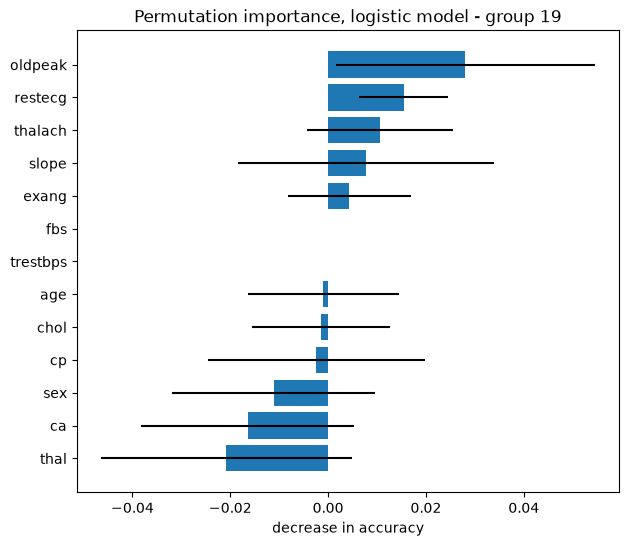

In [6]:
r = permutation_importance(logreg, X_test, y_test, n_repeats=30, random_state=S)

imp = pd.DataFrame({"mean": r.importances_mean, "std": r.importances_std},
                   index=X_test.columns).sort_values("mean")
plt.figure(figsize=(7, 6))
plt.barh(imp.index, imp["mean"], xerr=imp["std"])
plt.xlabel("decrease in accuracy")
plt.title(f"Permutation importance, logistic model - group {GROUP_NUMBER}")
plt.show()

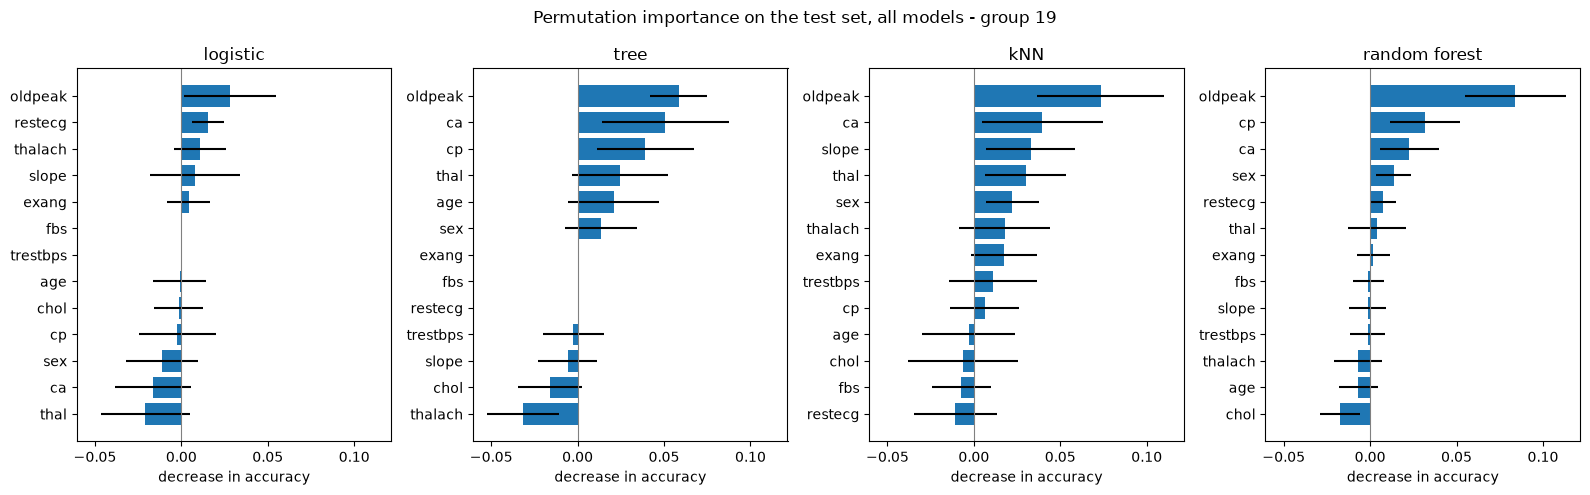

,logistic,tree,kNN,random forest
rank,,,,
1,oldpeak (0.028),oldpeak (0.058),oldpeak (0.073),oldpeak (0.084)
2,restecg (0.015),ca (0.051),ca (0.040),cp (0.032)
3,thalach (0.011),cp (0.039),slope (0.033),ca (0.023)
4,slope (0.008),thal (0.025),thal (0.030),sex (0.014)
5,exang (0.004),age (0.021),sex (0.022),restecg (0.008)


,test accuracy,largest importance,sum of importances,sum of |importances|
logistic,0.754,0.028,0.013,0.119
tree,0.696,0.058,0.152,0.263
kNN,0.768,0.073,0.224,0.278
random forest,0.812,0.084,0.131,0.200


In [7]:
# (b) permutation importance for all models, top 5 attributes of each model
perm = {name: permutation_importance(model, X_test, y_test, n_repeats=30, random_state=S)
        for name, model in models.items()}
perm_mean = pd.DataFrame({name: r.importances_mean for name, r in perm.items()}, index=X_test.columns)
perm_std = pd.DataFrame({name: r.importances_std for name, r in perm.items()}, index=X_test.columns)

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharex=True)
for ax, name in zip(axes, models):
    order = perm_mean[name].sort_values().index
    ax.barh(order, perm_mean.loc[order, name], xerr=perm_std.loc[order, name])
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(name)
    ax.set_xlabel("decrease in accuracy")
fig.suptitle(f"Permutation importance on the test set, all models - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

top5 = pd.DataFrame({name: [f"{a} ({v:.3f})" for a, v in perm_mean[name].nlargest(5).items()]
                     for name in models}, index=pd.Index(range(1, 6), name="rank"))
display(top5)

# how much does each model react to the shuffling in total?
pd.DataFrame({"test accuracy": perf["test accuracy"],
              "largest importance": perm_mean.max(),
              "sum of importances": perm_mean.sum(),
              "sum of |importances|": perm_mean.abs().sum()}).round(3)

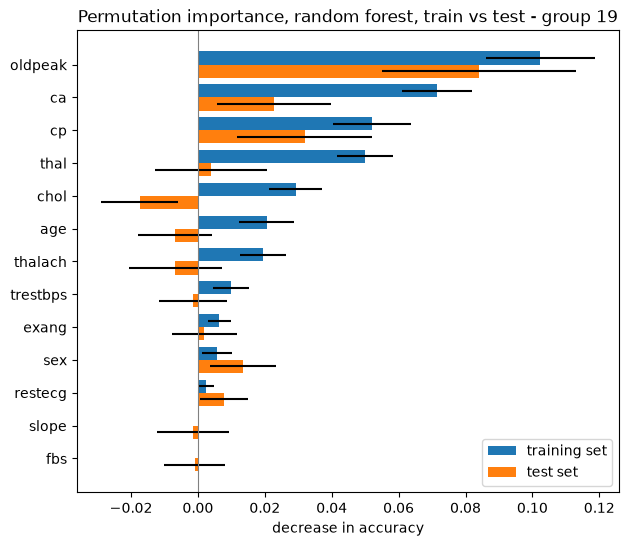

random forest accuracy: train 1.000, test 0.812


,train,train std,test,test std
oldpeak,0.102,0.016,0.084,0.029
ca,0.071,0.010,0.023,0.017
cp,0.052,0.012,0.032,0.020
thal,0.050,0.008,0.004,0.017
chol,0.029,0.008,-0.017,0.011
age,0.021,0.008,-0.007,0.011
thalach,0.019,0.007,-0.007,0.014
trestbps,0.010,0.005,-0.001,0.010
exang,0.006,0.003,0.002,0.010
sex,0.006,0.004,0.014,0.010


In [8]:
# (c) random forest: permutation importance on the training set and on the test set
r_train = permutation_importance(rf, X_train, y_train, n_repeats=30, random_state=S)
r_test = perm["random forest"]

rf_imp = pd.DataFrame({"train": r_train.importances_mean, "train std": r_train.importances_std,
                       "test": r_test.importances_mean, "test std": r_test.importances_std},
                      index=X_test.columns).sort_values("train")
pos = np.arange(len(rf_imp))
plt.figure(figsize=(7, 6))
plt.barh(pos + 0.2, rf_imp["train"], height=0.4, xerr=rf_imp["train std"], label="training set")
plt.barh(pos - 0.2, rf_imp["test"], height=0.4, xerr=rf_imp["test std"], label="test set")
plt.yticks(pos, rf_imp.index)
plt.axvline(0, color="grey", lw=0.8)
plt.xlabel("decrease in accuracy")
plt.legend()
plt.title(f"Permutation importance, random forest, train vs test - group {GROUP_NUMBER}")
plt.show()

print(f"random forest accuracy: train {rf.score(X_train, y_train):.3f}, test {rf.score(X_test, y_test):.3f}")
rf_imp.sort_values("train", ascending=False).round(3)

In [9]:
# (d) a copy of thalach with a little noise (std 1 beat/min, thalach itself has a std of about 23)
rng = np.random.default_rng(S)
X_train_d = X_train.assign(thalach_copy=X_train["thalach"] + rng.normal(0, 1, len(X_train)))
X_test_d = X_test.assign(thalach_copy=X_test["thalach"] + rng.normal(0, 1, len(X_test)))
print("correlation thalach - thalach_copy:", round(X_train_d["thalach"].corr(X_train_d["thalach_copy"]), 4))


def make_logreg(extra_num):
    pre = ColumnTransformer(
        [("num", StandardScaler(), num_cols + extra_num),
         ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
         ("bin", "passthrough", bin_cols)],
        verbose_feature_names_out=False).set_output(transform="pandas")
    return make_pipeline(pre, LogisticRegression(max_iter=1000))


def joint_importance(model, X_part, y_part, cols, n_repeats=30):
    """Decrease in accuracy when the columns in cols are shuffled together (same order for all of them)."""
    rng_j = np.random.default_rng(S)
    base = model.score(X_part, y_part)
    drops = []
    for _ in range(n_repeats):
        X_perm = X_part.copy()
        X_perm[cols] = X_part[cols].values[rng_j.permutation(len(X_part))]
        drops.append(base - model.score(X_perm, y_part))
    return np.mean(drops)


models_d = {"logistic": make_logreg(["thalach_copy"]).fit(X_train_d, y_train),
            "random forest": RandomForestClassifier(n_estimators=300, random_state=S).fit(X_train_d, y_train)}

rows = {}
for name, m in models_d.items():
    r_d = permutation_importance(m, X_test_d, y_test, n_repeats=30, random_state=S)
    imp_d = pd.Series(r_d.importances_mean, index=X_test_d.columns)
    rows[name] = {"thalach before": perm_mean.loc["thalach", name],
                  "rank before": int(perm_mean[name].rank(ascending=False)["thalach"]),
                  "thalach after": imp_d["thalach"],
                  "thalach_copy": imp_d["thalach_copy"],
                  "rank after": int(imp_d.rank(ascending=False)["thalach"]),
                  "both shuffled together": joint_importance(m, X_test_d, y_test, ["thalach", "thalach_copy"]),
                  "test accuracy before": models[name].score(X_test, y_test),
                  "test accuracy after": m.score(X_test_d, y_test)}
display(pd.DataFrame(rows).T.round(4))

# how the models divide the effect of thalach over the two columns
coef_before = pd.Series(logreg[-1].coef_[0], index=logreg[:-1].get_feature_names_out())
coef_d = pd.Series(models_d["logistic"][-1].coef_[0], index=models_d["logistic"][:-1].get_feature_names_out())
print(f"logistic beta: thalach before {coef_before['thalach']:.3f} -> "
      f"thalach {coef_d['thalach']:.3f} + thalach_copy {coef_d['thalach_copy']:.3f} "
      f"= {coef_d['thalach'] + coef_d['thalach_copy']:.3f}")
mdi_before = pd.Series(rf.feature_importances_, index=X_train.columns)
mdi_d = pd.Series(models_d["random forest"].feature_importances_, index=X_train_d.columns)
print(f"random forest feature_importances_: thalach before {mdi_before['thalach']:.3f} -> "
      f"thalach {mdi_d['thalach']:.3f} + thalach_copy {mdi_d['thalach_copy']:.3f}")

correlation thalach - thalach_copy: 0.9991


,thalach before,rank before,thalach after,thalach_copy,rank after,both shuffled together,test accuracy before,test accuracy after
logistic,0.0106,3.0,0.0010,0.0092,6.0,0.0150,0.7536,0.7536
random forest,-0.0068,11.0,0.0063,0.0063,9.0,0.0208,0.8116,0.8261


logistic beta: thalach before 0.203 -> thalach 0.060 + thalach_copy 0.151 = 0.211
random forest feature_importances_: thalach before 0.134 -> thalach 0.108 + thalach_copy 0.119


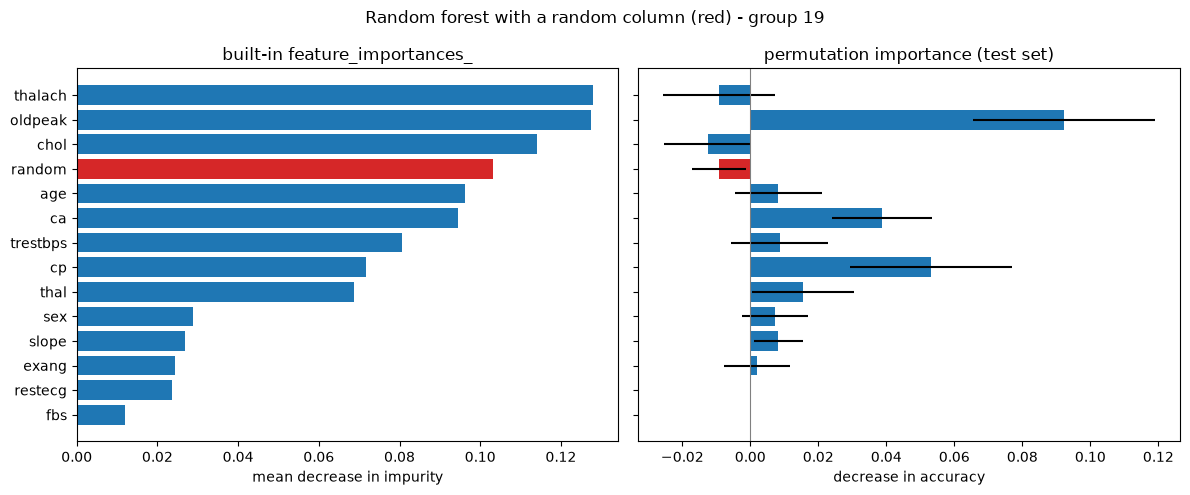

distinct values: {'random': 204, 'chol': 122, 'thalach': 75, 'sex': 2, 'fbs': 2, 'exang': 2}


,feature_importances_ (MDI),permutation (test),permutation std (test),permutation (train),rank MDI,rank permutation (test)
thalach,0.128,-0.009,0.017,0.013,1,12
oldpeak,0.127,0.092,0.027,0.076,2,1
chol,0.114,-0.013,0.013,0.022,3,14
random,0.103,-0.009,0.008,0.007,4,13
age,0.096,0.008,0.013,0.014,5,6
ca,0.095,0.039,0.015,0.065,6,3
trestbps,0.081,0.009,0.014,0.001,7,5
cp,0.072,0.053,0.024,0.032,8,2
thal,0.069,0.015,0.015,0.044,9,4
sex,0.029,0.007,0.010,0.004,10,8


In [10]:
# (e) a column of random numbers: built-in importance of the random forest vs permutation importance
rng = np.random.default_rng(S)
X_train_e = X_train.assign(random=rng.normal(size=len(X_train)))
X_test_e = X_test.assign(random=rng.normal(size=len(X_test)))
rf_e = RandomForestClassifier(n_estimators=300, random_state=S).fit(X_train_e, y_train)

r_e_test = permutation_importance(rf_e, X_test_e, y_test, n_repeats=30, random_state=S)
r_e_train = permutation_importance(rf_e, X_train_e, y_train, n_repeats=30, random_state=S)
imp_e = pd.DataFrame({"feature_importances_ (MDI)": rf_e.feature_importances_,
                      "permutation (test)": r_e_test.importances_mean,
                      "permutation std (test)": r_e_test.importances_std,
                      "permutation (train)": r_e_train.importances_mean},
                     index=X_test_e.columns)
imp_e["rank MDI"] = imp_e["feature_importances_ (MDI)"].rank(ascending=False).astype(int)
imp_e["rank permutation (test)"] = imp_e["permutation (test)"].rank(ascending=False).astype(int)
imp_e = imp_e.sort_values("feature_importances_ (MDI)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = ["tab:red" if c == "random" else "tab:blue" for c in imp_e.index]
axes[0].barh(imp_e.index, imp_e["feature_importances_ (MDI)"], color=colors)
axes[0].set_xlabel("mean decrease in impurity")
axes[0].set_title("built-in feature_importances_")
axes[1].barh(imp_e.index, imp_e["permutation (test)"], xerr=imp_e["permutation std (test)"], color=colors)
axes[1].axvline(0, color="grey", lw=0.8)
axes[1].set_xlabel("decrease in accuracy")
axes[1].set_title("permutation importance (test set)")
fig.suptitle(f"Random forest with a random column (red) - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

print("distinct values:", X_train_e[["random", "chol", "thalach", "sex", "fbs", "exang"]].nunique().to_dict())
imp_e.sort_values("rank MDI").round(3)

**Your answers:**

a) *Expectation.* In Lab 1 the largest odds ratios of our logistic model were `cp_2` (3.65), `oldpeak` (2.94 per standard deviation) and `slope_2` (2.02), so we expected `cp`, `oldpeak` and `slope` to come out on top.

*Result.* The bar is the average drop in test accuracy over 30 shuffles of one attribute. `oldpeak` is first (0.028 ± 0.027), then `restecg` (0.015), `thalach` (0.011), `slope` (0.008) and `exang` (0.004). So we were right about `oldpeak`, `slope` is 4th, and we were wrong about `cp`: its importance is −0.002 (rank 10).

All values are small. Our test set has 69 patients, so one patient is 0.0145 accuracy and the 0.028 of `oldpeak` is about 2 patients. For almost every attribute the error bar crosses zero, and 6 of the 13 values are negative (`thal` −0.021, `ca` −0.016, `sex` −0.011). A negative value means the model got a bit better after shuffling, which can only be chance. The reason `cp` is so low is that accuracy only changes when a prediction crosses 0.5. Our model predicts disease for most patients (70% of the data has disease), so a change of `cp` moves the probability but often does not flip the class. When we score with ROC-AUC instead (cell in Q3a), `cp` is 2nd (0.068) right behind `oldpeak` (0.070). So our expectation fits how the model uses the attributes, but not the accuracy-based plot.

b) We expected the tree and kNN to react the most. A tree gives hard 0/1 predictions, so one shuffled value on a split flips the whole prediction, and kNN gets different neighbours as soon as one scaled attribute changes. The logistic model spreads its decision over 19 coefficients and changes smoothly.

The results agree with this. The sum of the absolute importances is 0.278 for kNN, 0.263 for the tree, 0.200 for the random forest and only 0.119 for the logistic model. The largest single drop is `oldpeak` in the random forest (0.084).

| rank | logistic | tree | kNN | random forest |
|---|---|---|---|---|
| 1 | `oldpeak` (0.028) | `oldpeak` (0.058) | `oldpeak` (0.073) | `oldpeak` (0.084) |
| 2 | `restecg` (0.015) | `ca` (0.051) | `ca` (0.040) | `cp` (0.032) |
| 3 | `thalach` (0.011) | `cp` (0.039) | `slope` (0.033) | `ca` (0.023) |
| 4 | `slope` (0.008) | `thal` (0.025) | `thal` (0.030) | `sex` (0.014) |
| 5 | `exang` (0.004) | `age` (0.021) | `sex` (0.022) | `restecg` (0.008) |

`oldpeak` is first for all four models. `ca` is in the top 3 of the tree, kNN and the forest, but not of the logistic model.

c) On the training set all importances are zero or positive and the error bars are small: `oldpeak` 0.102, `ca` 0.071, `cp` 0.052, `thal` 0.050, `chol` 0.029, `age` 0.021, `thalach` 0.019. On the test set only `oldpeak` (0.084), `cp` (0.032) and `ca` (0.023) are clearly above zero. `thal` drops to 0.004, and `chol` (−0.017), `age` (−0.007) and `thalach` (−0.007) are negative.

The training version shows what the forest relies on, including what it memorised. The test version shows what helps on new patients. The forest has a training accuracy of 1.000 and a test accuracy of 0.812, so it overfits. The attributes that are important on train but not on test (`chol`, `age`, `thalach`, partly `thal`) are the ones it overfitted on. They are mostly continuous attributes with many possible split points. `oldpeak`, `cp` and `ca` are important on both sets, so we trust those.

d) We added `thalach_copy` = `thalach` + noise with standard deviation 1 (correlation 0.9991) and trained again.

Logistic model: the importance of `thalach` goes from 0.0106 (rank 3) to 0.0010 (rank 6), and the copy gets 0.0092. When we shuffle both columns together the drop is 0.0150. The coefficients show why: β was 0.203 for `thalach`, and now it is 0.060 for `thalach` plus 0.151 for the copy (together 0.211). The model divides the effect over the two columns. If we shuffle only one, the other still holds the same information, so the accuracy barely drops. Permutation importance therefore underestimates attributes that are correlated with another attribute, and the importance is shared between them.

Random forest: here we do not see it in the permutation importance, because `thalach` had no importance on the test set to begin with (−0.007 before, 0.006 for both columns after, all within the standard deviation of 0.014). The split is visible in the built-in importance, which goes from 0.134 to 0.108 + 0.119.

e) The built-in `feature_importances_` gives the random column 0.103, which is rank 4 of 14, above `age`, `ca`, `cp` and `thal`. Permutation importance on the test set gives it −0.009 ± 0.008 (rank 13), so no importance.

The built-in importance is the total decrease in impurity of all splits on an attribute, measured on the training data. Our trees are grown until every leaf is pure (training accuracy 1.000). A column with 204 distinct values offers a lot of split points, so some of them reduce impurity by chance, and the trees use them to separate the last few training patients. This favours attributes with many values: `thalach` (75 values), `chol` (122) and `random` (204) are ranks 1, 3 and 4, and the binary attributes `sex`, `exang` and `fbs` are at the bottom. Permutation importance on the test set asks if the predictions for new patients get worse, and for a random column they do not. It also puts `thalach` and `chol` at ranks 12 and 14. Even permutation importance on the training set gives the random column 0.007, because the forest memorised it.

## Q2) Partial dependence and ICE

a) **[Basic]** Choose the two attributes you think explain the most, and motivate your choice. For each model, plot the partial dependence plot (PDP) of these attributes together with the ICE curves. Comment on the differences between the models. Do all patients behave the same way? Point to a place in your plot where the PDP hides something.

b) **[Basic]** Plot the two-way PDP of `trestbps` (resting blood pressure) and `cp` (chest pain type) and explain their effect.

c) **[Advanced]** Write your own code for the Ceteris Paribus profile (algorithm in the lecture) of your patient for `thalach` and for `cp`. Compare it with the PDP.

d) **[Advanced]** Plot the PDP of the logistic model once on the probability scale and once on the log-odds scale. Why is one of them a straight line?

> **Hint:** `PartialDependenceDisplay.from_estimator(model, X_test, features, kind="both", centered=True)`;
> two-way: `features=[("trestbps", "cp")], categorical_features=["cp"]`; log-odds scale: `response_method="decision_function"`

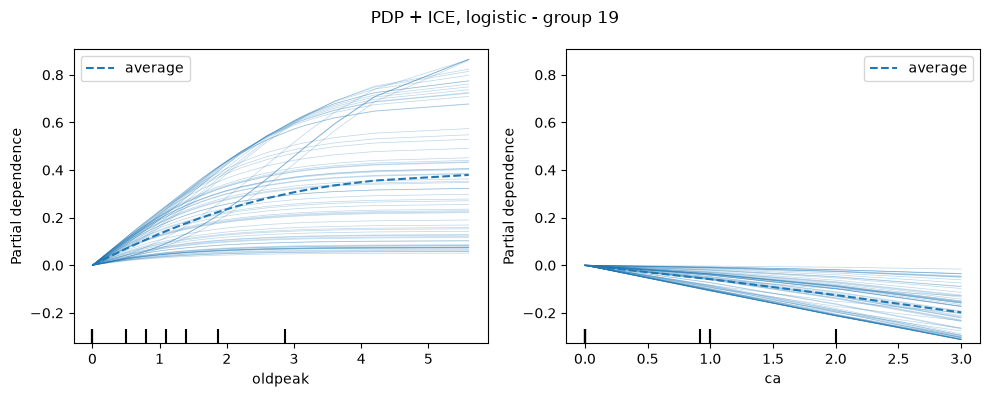

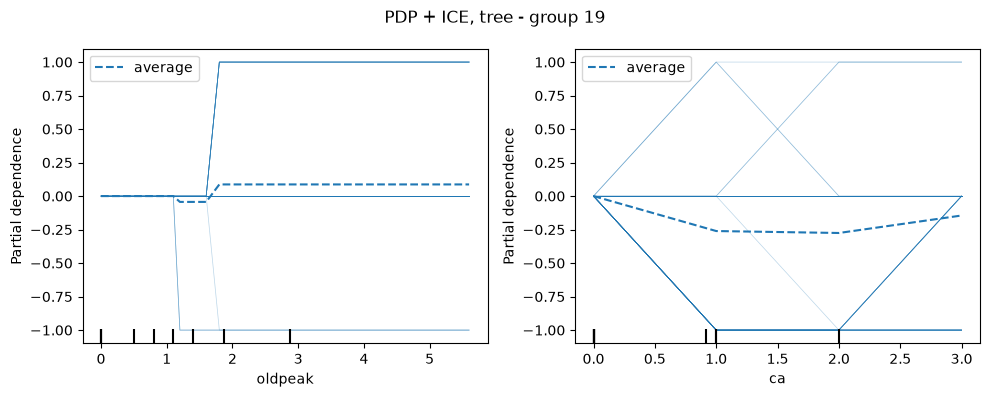

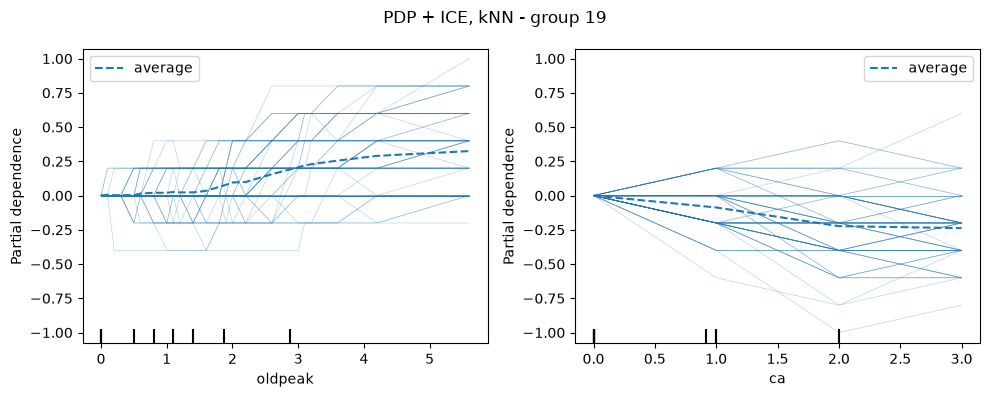

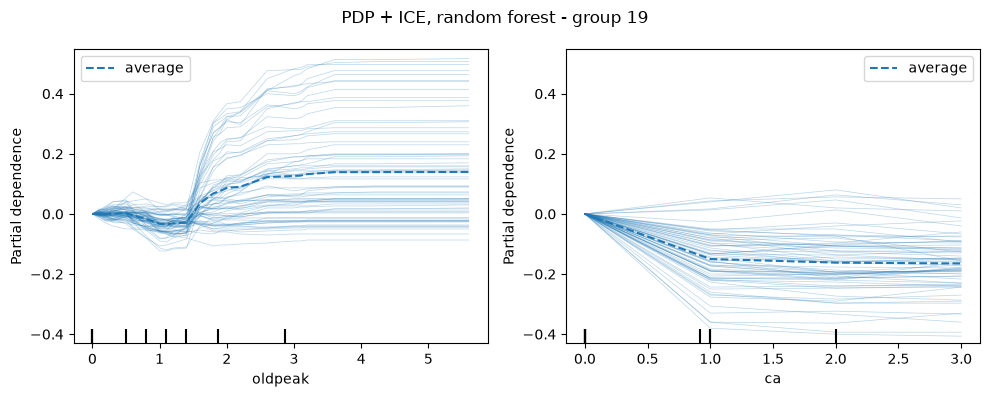

In [11]:
features = ["oldpeak", "ca"]  # (a): the two attributes we think explain the most

for name, model in models.items():
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    disp = PartialDependenceDisplay.from_estimator(
        model, X_test, features, kind="both", centered=True, random_state=S, ax=ax)
    disp.figure_.suptitle(f"PDP + ICE, {name} - group {GROUP_NUMBER}")
    plt.tight_layout()
    plt.show()

In [12]:
# (a) numbers behind the plots: our own ICE curves, to see if all patients behave the same way
def ice_curves(model, X_part, feature, grid):
    """One row per patient, one column per grid value: P(disease) when only `feature` is changed."""
    out = np.empty((len(X_part), len(grid)))
    for k, value in enumerate(grid):
        X_mod = X_part.copy()
        X_mod[feature] = value
        out[:, k] = model.predict_proba(X_mod)[:, 1]
    return pd.DataFrame(out, index=X_part.index, columns=grid)


rows = []
for feature in features:
    lo, hi = X_test[feature].min(), X_test[feature].max()
    for name, model in models.items():
        ice = ice_curves(model, X_test, feature, [lo, hi])
        change = ice[hi] - ice[lo]
        rows.append({"attribute": f"{feature}: {lo:g} -> {hi:g}", "model": name,
                     "PDP change": change.mean(), "smallest ICE change": change.min(),
                     "largest ICE change": change.max(), "std of ICE change": change.std(),
                     "patients going up": int((change > 0.01).sum()),
                     "flat": int((change.abs() <= 0.01).sum()),
                     "going down": int((change < -0.01).sum())})
pd.DataFrame(rows).set_index(["attribute", "model"]).round(3)

PDP change  smallest ICE change  \
attribute         model                                            
oldpeak: 0 -> 5.6 logistic            0.379                0.051   
                  tree                0.087               -1.000   
                  kNN                 0.325               -0.200   
                  random forest       0.140               -0.087   
ca: 0 -> 3        logistic           -0.198               -0.313   
                  tree               -0.145               -1.000   
                  kNN                -0.238               -0.800   
                  random forest      -0.165               -0.407   

                                 largest ICE change  std of ICE change  \
attribute         model                                                  
oldpeak: 0 -> 5.6 logistic                    0.865              0.277   
                  tree                        1.000              0.445   
                  kNN                         1.000              0.293   
                  random forest               0.517              0.165   
ca: 0 -> 3        logistic                   -0.016              0.093   
                  tree                        1.000              0.463   
                  kNN                         0.600              0.250   
                  random forest               0.050              0.095   

                                 patients going up  flat  going down  
attribute         model                                               
oldpeak: 0 -> 5.6 logistic                      69     0           0  
                  tree                          10    55           4  
                  kNN                           47    21           1  
                  random forest                 52     2          15  
ca: 0 -> 3        logistic                       0     0          69  
                  tree                           3    53          13  
                  kNN                            7     9          53  
                  random forest                  4     0          65

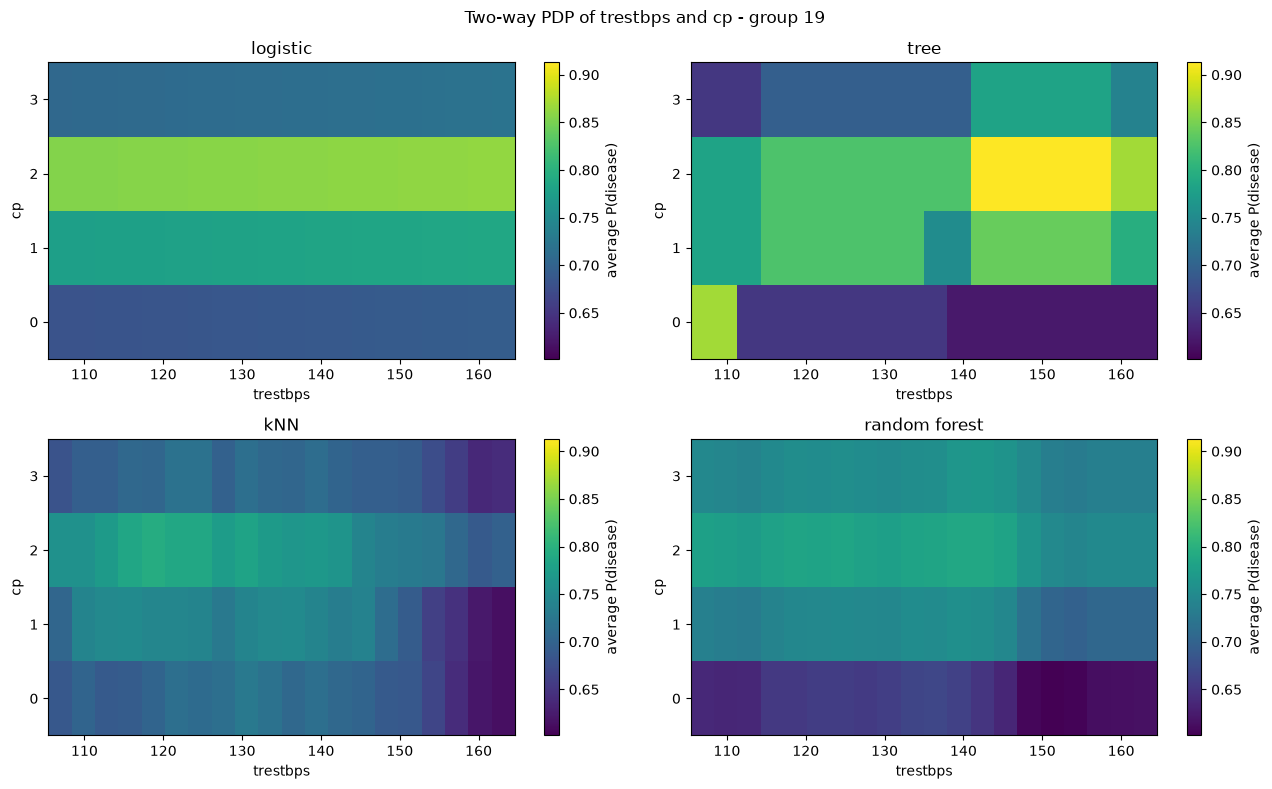

In [13]:
# (b) two-way PDP of trestbps and cp.
# PartialDependenceDisplay.from_estimator(model, X_test, [("trestbps", "cp")], categorical_features=["cp"])
# stops with "Two-way partial dependence plots are not supported for pairs of continuous and categorical
# features" in our scikit-learn version, so we compute the same thing ourselves: set trestbps and cp to
# a grid value for all test patients and average the predictions.
grid_bp = np.linspace(X_test["trestbps"].quantile(0.05), X_test["trestbps"].quantile(0.95), 20)
cp_values = [0.0, 1.0, 2.0, 3.0]
two_way = {name: pd.DataFrame({cp_value: ice_curves(model, X_test.assign(cp=cp_value), "trestbps", grid_bp).mean()
                               for cp_value in cp_values})
           for name, model in models.items()}
vmin = min(t.values.min() for t in two_way.values())
vmax = max(t.values.max() for t in two_way.values())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, name in zip(axes.ravel(), models):
    im = ax.imshow(two_way[name].T.values, aspect="auto", origin="lower", cmap="viridis", vmin=vmin, vmax=vmax,
                   extent=[grid_bp[0], grid_bp[-1], -0.5, 3.5])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_xlabel("trestbps")
    ax.set_ylabel("cp")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, label="average P(disease)")
fig.suptitle(f"Two-way PDP of trestbps and cp - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

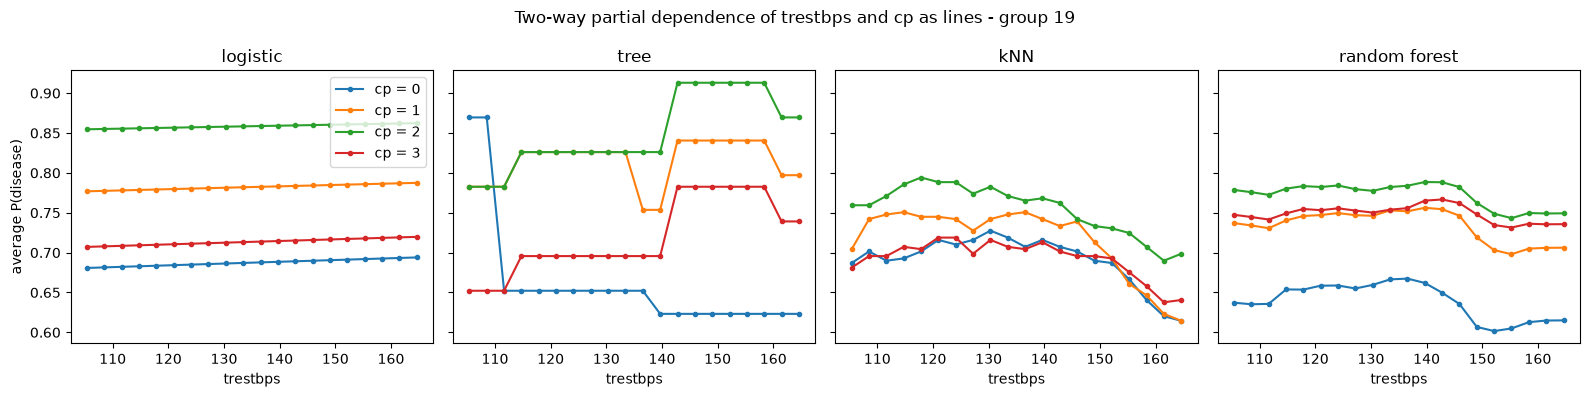

trestbps grid: 105 to 165 mm Hg


mean P(disease) per cp                              \
                  logistic   tree    kNN random forest   
0.0                  0.687  0.661  0.691         0.639   
1.0                  0.782  0.814  0.716         0.734   
2.0                  0.859  0.850  0.755         0.772   
3.0                  0.713  0.720  0.693         0.749   

    change over trestbps per cp                              
                       logistic   tree    kNN random forest  
0.0                       0.013 -0.246 -0.072        -0.022  
1.0                       0.011  0.014 -0.090        -0.031  
2.0                       0.008  0.087 -0.061        -0.029  
3.0                       0.013  0.087 -0.041        -0.012

In [14]:
# (b) the same numbers as lines: average P(disease) along trestbps, one line per chest pain type
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, name in zip(axes, models):
    for cp_value in cp_values:
        ax.plot(grid_bp, two_way[name][cp_value], marker=".", label=f"cp = {cp_value:g}")
    ax.set_title(name)
    ax.set_xlabel("trestbps")
axes[0].set_ylabel("average P(disease)")
axes[0].legend()
fig.suptitle(f"Two-way partial dependence of trestbps and cp as lines - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

# effect of cp (averaged over trestbps) and effect of trestbps (from 5% to 95% quantile, per cp)
print(f"trestbps grid: {grid_bp[0]:.0f} to {grid_bp[-1]:.0f} mm Hg")
pd.concat({"mean P(disease) per cp": pd.DataFrame({n: t.mean() for n, t in two_way.items()}),
           "change over trestbps per cp": pd.DataFrame({n: t.iloc[-1] - t.iloc[0] for n, t in two_way.items()})},
          axis=1).round(3)

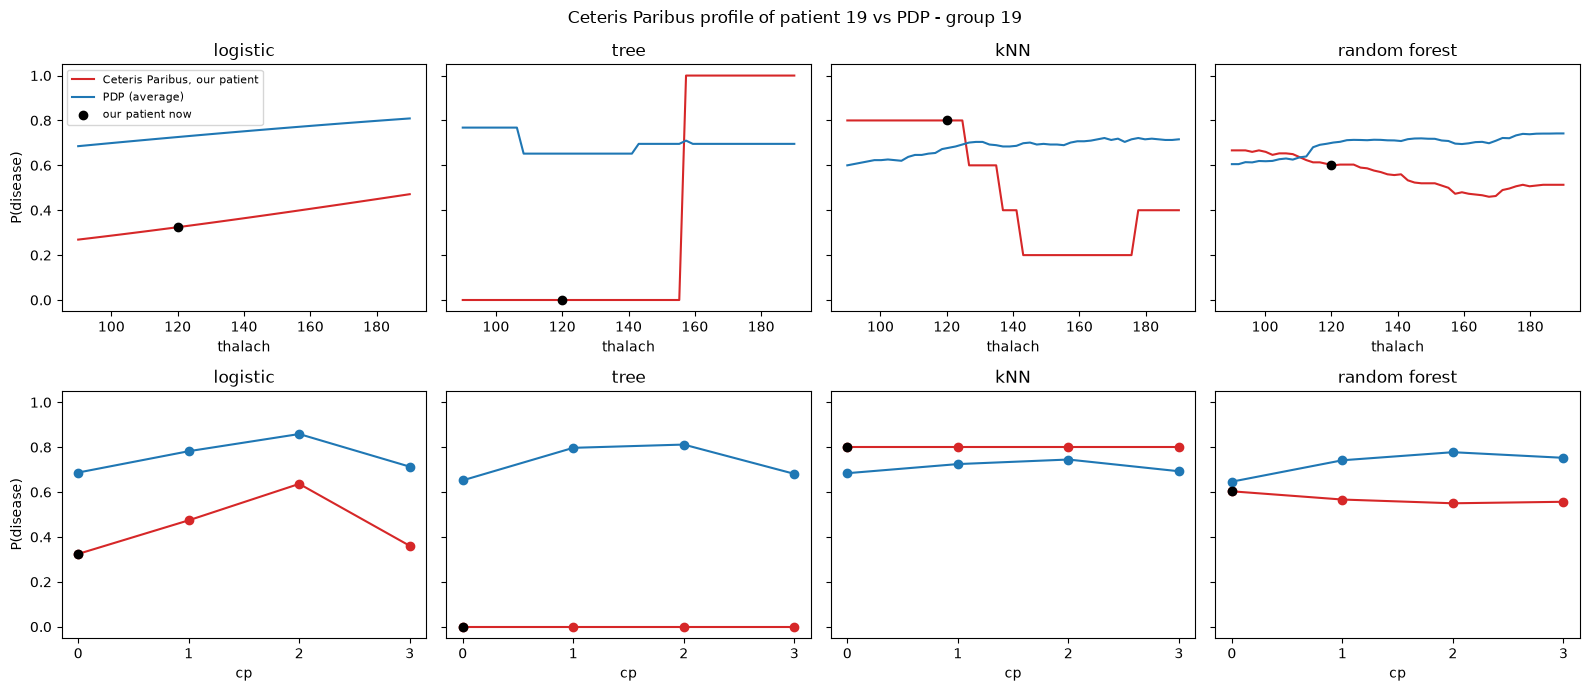

cp profile and PDP per model:


logistic              tree               kNN        random forest       
    CP patient    PDP CP patient    PDP CP patient    PDP    CP patient    PDP
0.0      0.324  0.687        0.0  0.652        0.8  0.684         0.603  0.646
1.0      0.474  0.782        0.0  0.797        0.8  0.725         0.567  0.742
2.0      0.636  0.859        0.0  0.812        0.8  0.745         0.550  0.778
3.0      0.360  0.713        0.0  0.681        0.8  0.693         0.557  0.753

thalach: P(disease) at the lowest, the patient's own and the highest value


,CP at min,CP at patient value,CP at max,CP range,PDP at min,PDP at max,PDP range
logistic,0.269,0.324,0.471,0.202,0.685,0.809,0.124
tree,0.000,0.000,1.000,1.000,0.768,0.696,0.116
kNN,0.800,0.800,0.400,0.600,0.600,0.716,0.122
random forest,0.667,0.603,0.513,0.207,0.605,0.742,0.137


In [15]:
# (c) Ceteris Paribus profile of our patient, with our own code:
#     take the patient, change one attribute over a grid, keep all the others, and predict again.
def ceteris_paribus(model, x, feature, grid):
    X_cp = pd.concat([x] * len(grid), ignore_index=True)
    X_cp[feature] = grid
    return pd.Series(model.predict_proba(X_cp)[:, 1], index=grid)


grids = {"thalach": np.linspace(X_test["thalach"].min(), X_test["thalach"].max(), 50),
         "cp": np.array([0.0, 1.0, 2.0, 3.0])}

cp_profiles = {}
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for row, (feature, grid) in zip(axes, grids.items()):
    for ax, (name, model) in zip(row, models.items()):
        profile = ceteris_paribus(model, x_p, feature, grid)
        pdp = ice_curves(model, X_test, feature, grid).mean()     # PDP = average of all the profiles
        cp_profiles[(feature, name)] = pd.DataFrame({"CP patient": profile, "PDP": pdp})
        style = "o-" if feature == "cp" else "-"
        ax.plot(grid, profile, style, color="tab:red", label="Ceteris Paribus, our patient")
        ax.plot(grid, pdp, style, color="tab:blue", label="PDP (average)")
        ax.scatter(x_p[feature], model.predict_proba(x_p)[:, 1], color="black", zorder=3, label="our patient now")
        ax.set_title(name)
        ax.set_xlabel(feature)
        if feature == "cp":
            ax.set_xticks(grid)
    row[0].set_ylabel("P(disease)")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Ceteris Paribus profile of patient {p} vs PDP - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

print("cp profile and PDP per model:")
display(pd.concat({name: cp_profiles[("cp", name)] for name in models}, axis=1).round(3))
print("thalach: P(disease) at the lowest, the patient's own and the highest value")
x_thalach = x_p["thalach"].iloc[0]
pd.DataFrame({name: {"CP at min": d["CP patient"].iloc[0],
                     "CP at patient value": models[name].predict_proba(x_p)[0, 1],
                     "CP at max": d["CP patient"].iloc[-1],
                     "CP range": d["CP patient"].max() - d["CP patient"].min(),
                     "PDP at min": d["PDP"].iloc[0], "PDP at max": d["PDP"].iloc[-1],
                     "PDP range": d["PDP"].max() - d["PDP"].min()}
              for name in models for d in [cp_profiles[("thalach", name)]]}).T.round(3)

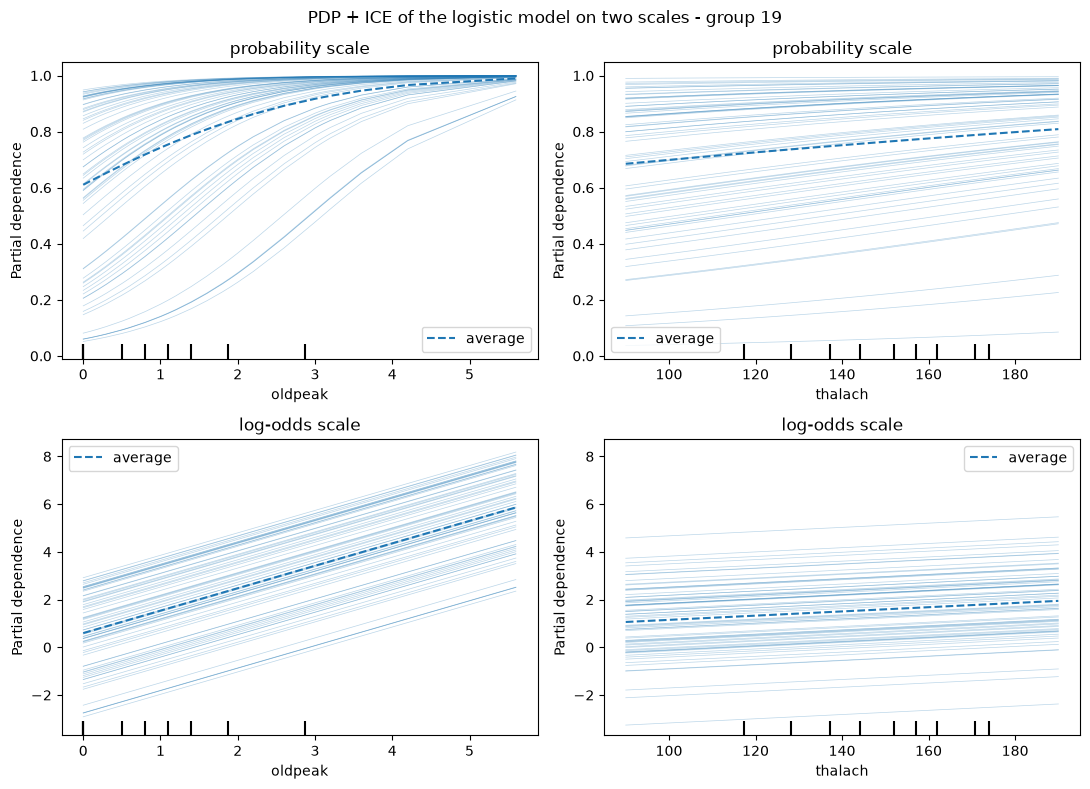

predict_proba      slope per unit of oldpeak: first step 0.1437, last step 0.0169
decision_function  slope per unit of oldpeak: first step 0.9403, last step 0.9403
beta_oldpeak / std(oldpeak) = 1.0780 / 1.1464 = 0.9403


In [16]:
# (d) PDP of the logistic model on the probability scale and on the log-odds scale
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (method, label) in zip(axes, [("predict_proba", "probability"), ("decision_function", "log-odds")]):
    PartialDependenceDisplay.from_estimator(
        logreg, X_test, ["oldpeak", "thalach"], kind="both", response_method=method,
        random_state=S, ax=row)
    for ax in row:
        ax.set_title(f"{label} scale")
fig.suptitle(f"PDP + ICE of the logistic model on two scales - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

# is the PDP a straight line? compare the slope of the first and of the last grid step
from sklearn.inspection import partial_dependence
for method in ["predict_proba", "decision_function"]:
    pdr = partial_dependence(logreg, X_test, ["oldpeak"], response_method=method, kind="average")
    xs, ys = pdr["grid_values"][0], pdr["average"][0]
    slopes = np.diff(ys) / np.diff(xs)
    print(f"{method:18s} slope per unit of oldpeak: first step {slopes[0]:.4f}, last step {slopes[-1]:.4f}")
beta_oldpeak = logreg[-1].coef_[0][list(logreg[:-1].get_feature_names_out()).index("oldpeak")]
sd_oldpeak = logreg[0].named_transformers_["num"].scale_[num_cols.index("oldpeak")]
print(f"beta_oldpeak / std(oldpeak) = {beta_oldpeak:.4f} / {sd_oldpeak:.4f} = {beta_oldpeak / sd_oldpeak:.4f}")

**Your answers:**

a) We chose `oldpeak` and `ca`. `oldpeak` is rank 1 in the permutation importance of all four models (0.028 to 0.084) and had the largest numerical coefficient in Lab 1 (β = 1.078). `ca` is rank 2 for the tree and kNN, rank 3 for the forest, and it is the root split of our tree (`ca` ≤ 0.5). Both are numerical, so a curve makes sense (`cp` is also important, but it is categorical).

The plots are centred, so every curve starts at 0. The table under the plots gives the change in P(disease) per patient between the lowest and highest value.

- **Logistic**: smooth curves in one direction. From `oldpeak` 0 to 5.6 the PDP goes up by 0.379, and from `ca` 0 to 3 it goes down by 0.198. All 69 patients go the same way, but not by the same amount: for `oldpeak` between +0.051 and +0.865. Patients who are already close to probability 1 have little room left.
- **Tree**: steps. For `oldpeak` 55 of 69 patients do not react at all, 10 jump from 0 to 1 around `oldpeak` 1.6, and 4 go from 1 to 0. For `ca` 53 are flat, 13 go down and 3 go up.
- **kNN**: steps of 0.2 (one of the 5 neighbours changes). `oldpeak`: +0.325 on average, 47 up, 21 flat and 1 down. `ca`: −0.238, 53 down and 7 up.
- **Random forest**: for `oldpeak` a small dip (about −0.03) between 1 and 1.4, a steep rise between 1.4 and 2, and then flat at +0.14. For `ca` a drop of about 0.15 from 0 to 1 and then flat, so the forest only looks at "no vessel" against "one or more".

So the patients do not all behave the same way. Only in the logistic model is the direction the same for everyone. The PDP hides the most in the `oldpeak` plot of the tree: the average rises by only 0.087, which looks like a weak effect, but in fact 10 patients flip from no disease to disease, 4 flip the other way and 55 do nothing. The same happens in the forest, where the average of +0.140 hides 15 patients whose risk goes down with a higher `oldpeak` (to −0.087) and some who go up by +0.517.

b) `PartialDependenceDisplay` with `categorical_features=["cp"]` raises an error in our scikit-learn version for a numerical and a categorical attribute together, so we computed the two-way PDP ourselves (set both attributes for all test patients and average). We used `trestbps` from 105 to 165 mm Hg (5% to 95% quantile).

`cp` has a clear effect and `trestbps` has almost none. In the logistic model the plot has four horizontal bands: average P(disease) is 0.687 for `cp` 0, 0.782 for `cp` 1, 0.859 for `cp` 2 and 0.713 for `cp` 3. Going from 105 to 165 mm Hg changes the probability by about +0.01 in every band. The bands do not change with `trestbps`, so there is no interaction, as expected for an additive model. The forest gives the same picture: `cp` 0 is lowest (0.639), types 1 to 3 are between 0.734 and 0.772, and `trestbps` changes at most −0.031. kNN goes down slightly with higher blood pressure (−0.04 to −0.09). Only the tree shows an interaction: for `cp` 0 the probability drops by 0.246 from low to high `trestbps`, and for `cp` 2 and 3 it rises by 0.087. These blocks come from single splits deep in an overfitted tree, so we do not trust them.

This fits what we found before: `trestbps` had a correlation of −0.019 with the target in Lab 1 and a permutation importance of 0.000. A caveat is that some combinations in the grid are rare in the data, so parts of the plot are extrapolation.

c) Our code takes the patient, replaces one attribute by every value of a grid, keeps the other 12 attributes, and predicts again. This is one ICE curve. The PDP is the average of these curves over all test patients.

`thalach` (our patient has 120):
- Logistic: the profile rises from 0.269 (at 90) through 0.324 (his own value) to 0.471 (at 190). The PDP rises from 0.685 to 0.809. The shape is the same, but his curve is about 0.34 to 0.42 lower, because his other attributes (`ca` = 2, `thal` = 3, male) pull him down.
- Tree: 0 until `thalach` is about 155 and then a jump to 1. This is the split `thalach` ≤ 155.5 on his path in Lab 1. The PDP is nearly flat (0.77 to 0.70) and does not show this.
- kNN: 0.8 at his own value, and it falls to 0.2 between about 143 and 176. The PDP goes up (0.600 to 0.716).
- Random forest: goes down from 0.667 to 0.513, and the PDP goes up from 0.605 to 0.742.

`cp` (our patient has 0):
- Logistic: 0.324, 0.474, 0.636 and 0.360 for `cp` 0 to 3. With `cp` 2 he would be classified as disease. The PDP has the same pattern (0.687, 0.782, 0.859, 0.713).
- Tree and kNN: no change (0.0 and 0.8 for every value), because `cp` is not on his path and does not change his neighbours enough.
- Random forest: slightly down (0.603 to 0.550), and the PDP goes up (0.646 to 0.778).

The PDP is the global average and the Ceteris Paribus profile is the what-if of one patient. For the additive logistic model the two have the same shape. For kNN and the forest our patient even goes against the average for `thalach`, so the PDP would give a wrong explanation for him.

d) On the log-odds scale the PDP of `oldpeak` is a straight line: the slope is 0.9403 per unit at the first and at the last grid step. This equals β / std = 1.0780 / 1.1464 = 0.9403. On the probability scale the curve bends: the slope is 0.1437 at the first step and 0.0169 at the last.

The logistic model is linear in the log-odds: z = β₀ + Σ βⱼxⱼ. One unit of `oldpeak` always adds the same amount to z, whatever the other attributes are. So every ICE curve is a straight line with the same slope, the curves are parallel, and their average is a straight line too. The probability is p = 1 / (1 + e^(−z)), an S-shaped function of z. The same step in z gives a large step in p around 0.5 and a small step near 0 or 1, so the ICE curves bend, each at a different place, and their average bends as well. For `thalach` the probability curve looks almost straight, because the effect is small (β = 0.203).

## Q3) SHAP

*Note:* for the force plot the notebook must be trusted (`shap.initjs()`).

a) **[Basic]** Use a SHAP explainer to derive the SHAP values for the logistic model (code below). Plot a SHAP summary plot using all attributes and explain the plot. Compare the order of the attributes with permutation importance.

b) **[Basic]** Plot the SHAP dependence plot for `exang`. Explain how to read this plot, and how it differs from a PDP.

c) **[Basic]** Plot a force plot and a waterfall plot for your patient and explain the figures. Check that the base value plus the sum of the SHAP values equals the model output for your patient. Give the numbers.

d) **[Regular]** For the logistic model, the SHAP value of attribute $j$ is $\beta_j (x_j - \text{mean}(x_j))$ on the log-odds scale. Check this for your patient with your numbers.

e) **[Advanced]** Find a patient in your test set whose most important attribute (by SHAP) is not the globally most important one. Explain why this is not a contradiction.

f) **[Advanced]** Use KernelSHAP with a background of 10, 50 and 200 patients. How much do the SHAP values change? How long does each run take?

> **Hint:** `shap.plots.beeswarm(sv)`, `shap.plots.bar(sv)`, `shap.plots.scatter(sv[:, "exang"], color=sv)`;
> `shap.plots.waterfall(sv[p])`, `shap.plots.force(sv[p])`; `sv.base_values[p]`, `sv.values[p].sum()`, `clf.decision_function(Xt_test)[p]`;
> `shap.KernelExplainer(f, shap.sample(X_train, 50, random_state=S))`

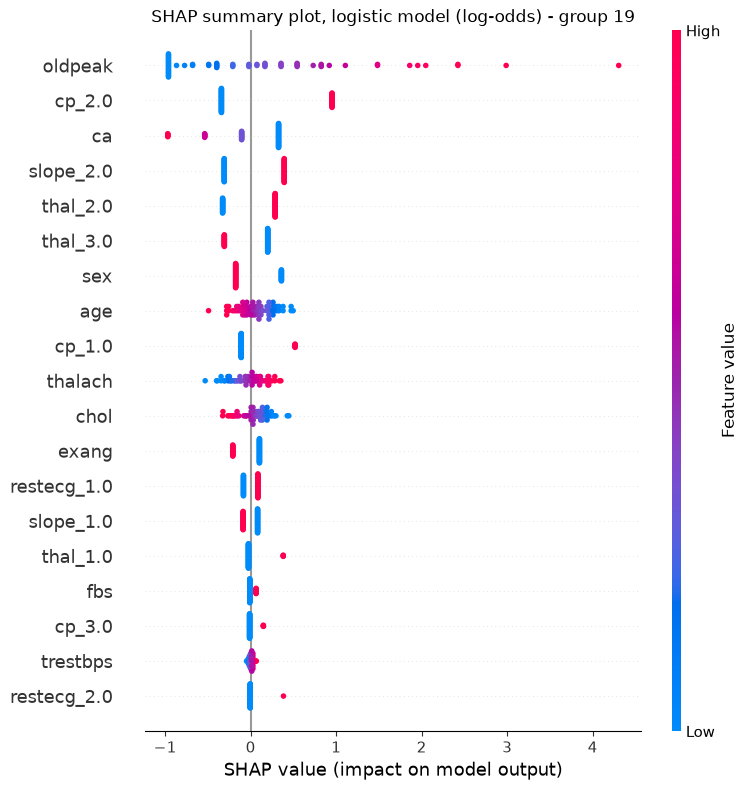

In [17]:
shap.initjs()

# SHAP for the logistic model, on the preprocessed (scaled) data.
# The values are on the log-odds scale.
pre, clf = logreg[:-1], logreg[-1]
Xt_train, Xt_test = pre.transform(X_train), pre.transform(X_test)

# Use the full training set as background (by default SHAP keeps only 100 rows)
masker = shap.maskers.Independent(Xt_train, max_samples=len(Xt_train))
explainer = shap.LinearExplainer(clf, masker)
sv = explainer(Xt_test)

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title(f"SHAP summary plot, logistic model (log-odds) - group {GROUP_NUMBER}")
plt.show()

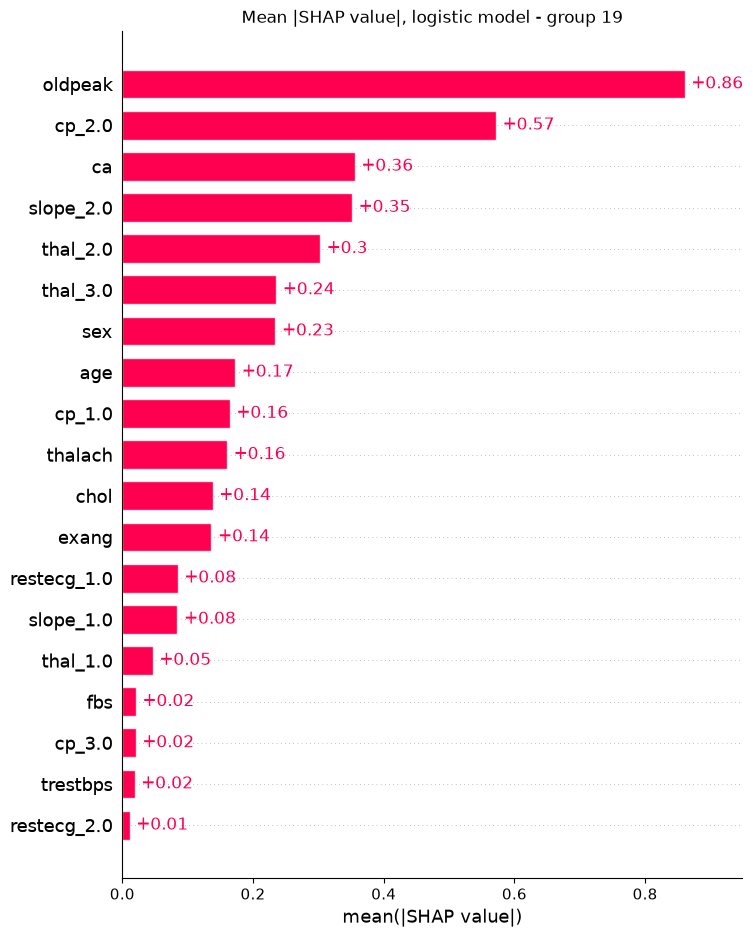

Spearman correlation of the SHAP ranking with permutation importance: accuracy -0.217 - ROC-AUC 0.973
attributes with a negative accuracy importance: 6 of 13


,mean |SHAP| (log-odds),permutation (accuracy),permutation (ROC-AUC),rank SHAP,rank perm acc,rank perm AUC
oldpeak,0.861,0.028,0.070,1,1,1
cp,0.554,-0.002,0.068,2,10,2
thal,0.515,-0.021,0.064,3,13,3
slope,0.426,0.008,0.034,4,4,4
ca,0.356,-0.016,0.020,5,12,6
sex,0.234,-0.011,0.021,6,11,5
age,0.173,-0.001,0.008,7,8,7
thalach,0.160,0.011,0.007,8,3,8
chol,0.138,-0.001,0.003,9,9,10
exang,0.136,0.004,0.000,10,5,11


In [18]:
# (a) global importance = mean |SHAP value|, compared with permutation importance.
# SHAP works on the 19 preprocessed columns and permutation importance on the 13 original attributes,
# so we add the SHAP values of the dummies of one attribute (SHAP values are additive).
shap.plots.bar(sv, max_display=20, show=False)
plt.title(f"Mean |SHAP value|, logistic model - group {GROUP_NUMBER}")
plt.show()


def per_attribute(values, columns):
    """Sum the SHAP values of the one-hot dummies, so that there is one column per original attribute."""
    values = pd.DataFrame(values, columns=columns)
    original = [c.rsplit("_", 1)[0] if c.rsplit("_", 1)[0] in cat_cols else c for c in columns]
    return values.T.groupby(original).sum().T[list(X_test.columns)]


sv_attr = per_attribute(sv.values, sv.feature_names)
r_auc = permutation_importance(logreg, X_test, y_test, n_repeats=30, random_state=S, scoring="roc_auc")
compare = pd.DataFrame({"mean |SHAP| (log-odds)": sv_attr.abs().mean(),
                        "permutation (accuracy)": perm_mean["logistic"],
                        "permutation (ROC-AUC)": r_auc.importances_mean})
for col, short in [("mean |SHAP| (log-odds)", "SHAP"), ("permutation (accuracy)", "perm acc"),
                   ("permutation (ROC-AUC)", "perm AUC")]:
    compare[f"rank {short}"] = compare[col].rank(ascending=False).astype(int)
print("Spearman correlation of the SHAP ranking with permutation importance: accuracy",
      round(compare["mean |SHAP| (log-odds)"].corr(compare["permutation (accuracy)"], method="spearman"), 3),
      "- ROC-AUC",
      round(compare["mean |SHAP| (log-odds)"].corr(compare["permutation (ROC-AUC)"], method="spearman"), 3))
print("attributes with a negative accuracy importance:", int((perm_mean["logistic"] < 0).sum()), "of 13")
compare.sort_values("rank SHAP").round(3)

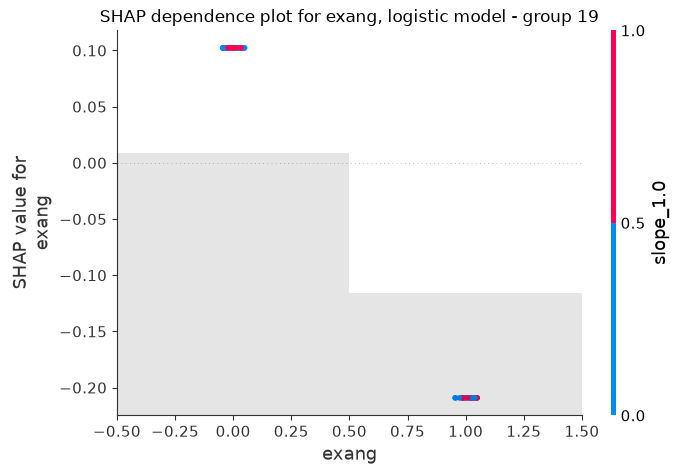

       count    mean     min     max
exang                               
0.0       47  0.1023  0.1023  0.1023
1.0       22 -0.2091 -0.2091 -0.2091
share of exang = 1 in the training set: 0.3284 - beta_exang: -0.3114


In [19]:
# (b) dependence plot for exang
shap.plots.scatter(sv[:, "exang"], color=sv, show=False)
plt.title(f"SHAP dependence plot for exang, logistic model - group {GROUP_NUMBER}")
plt.show()

print(pd.DataFrame({"exang": Xt_test["exang"].values, "SHAP": sv[:, "exang"].values})
      .groupby("exang")["SHAP"].agg(["count", "mean", "min", "max"]).round(4))
print("share of exang = 1 in the training set:", round(Xt_train["exang"].mean(), 4),
      "- beta_exang:", round(clf.coef_[0][list(Xt_train.columns).index("exang")], 4))

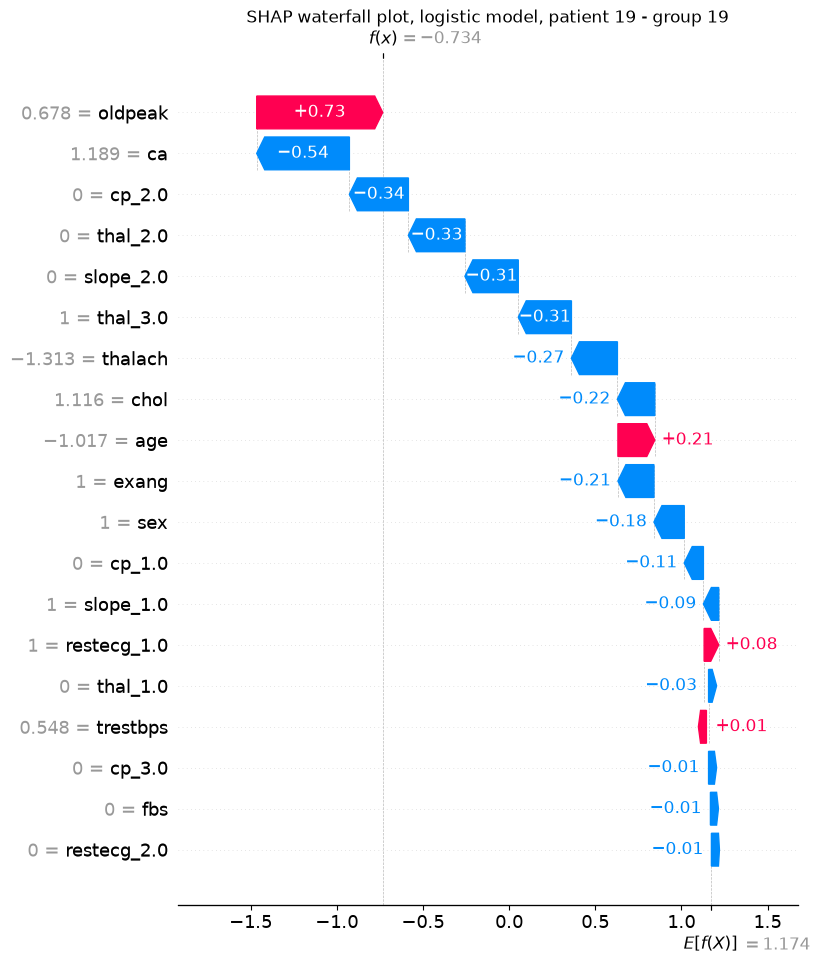

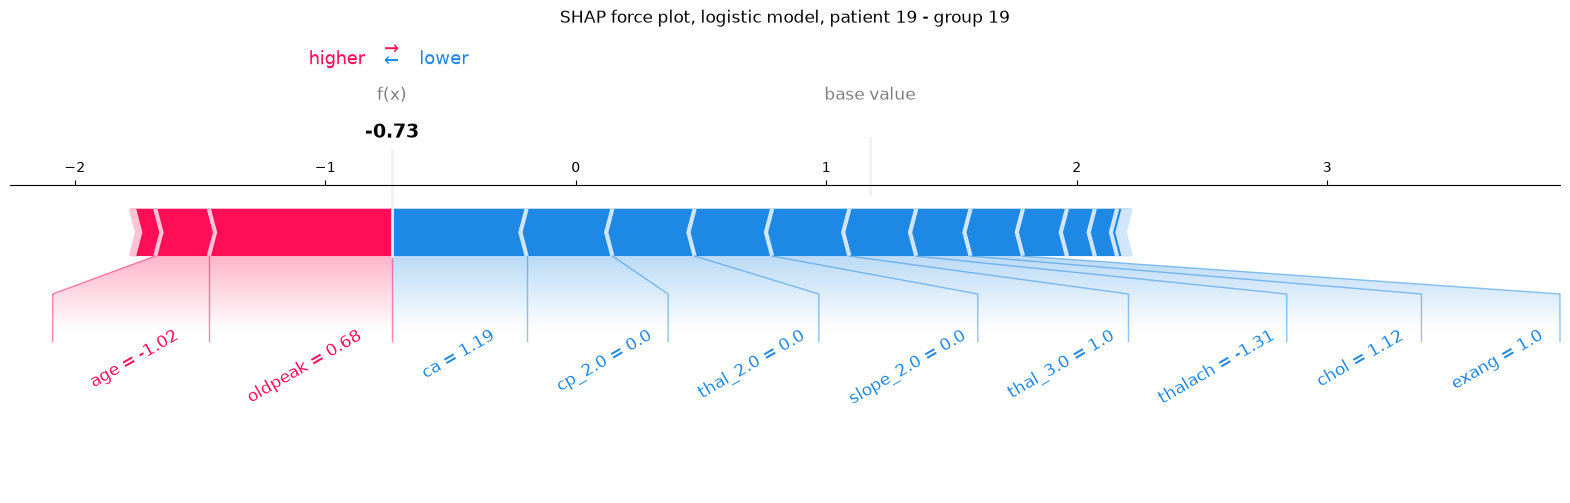

In [20]:
# (c) your patient
shap.plots.waterfall(sv[p], max_display=20, show=False)
plt.title(f"SHAP waterfall plot, logistic model, patient {p} - group {GROUP_NUMBER}")
plt.show()

# static version of the force plot (values rounded, labels only for the larger contributions)
shap.plots.force(sv.base_values[p], sv.values[p], Xt_test.iloc[p].round(2), matplotlib=True, show=False,
                 figsize=(20, 4), text_rotation=30, contribution_threshold=0.07)
plt.title(f"SHAP force plot, logistic model, patient {p} - group {GROUP_NUMBER}", y=1.5)
plt.show()
shap.plots.force(sv[p])     # interactive version (the notebook must be trusted)

In [21]:
# (c) check that base value + sum of SHAP values = model output (log-odds)
base = sv.base_values[p]
shap_sum = sv.values[p].sum()
output = clf.decision_function(Xt_test)[p]
print(f"base value                 = {base:.4f}   (mean log-odds of the training set: "
      f"{clf.decision_function(Xt_train).mean():.4f})")
print(f"sum of the SHAP values     = {shap_sum:.4f}")
print(f"base value + sum           = {base + shap_sum:.4f}")
print(f"model output (log-odds)    = {output:.4f}")
print(f"as a probability           = {1 / (1 + np.exp(-output)):.4f}"
      f"   (predict_proba: {logreg.predict_proba(x_p)[0, 1]:.4f})")
print(f"base value as a probability = {1 / (1 + np.exp(-base)):.4f}")
print("equal:", np.isclose(base + shap_sum, output))

base value                 = 1.1739   (mean log-odds of the training set: 1.1739)
sum of the SHAP values     = -1.9077
base value + sum           = -0.7338
model output (log-odds)    = -0.7338
as a probability           = 0.3244   (predict_proba: 0.3244)
base value as a probability = 0.7639
equal: True


In [22]:
# (d) SHAP value of attribute j = beta_j * (x_j - mean(x_j)), with the mean over the background (training set)
beta = pd.Series(clf.coef_[0], index=Xt_train.columns)
check = pd.DataFrame({"beta": beta,
                      "x_j (patient)": Xt_test.iloc[p],
                      "mean(x_j)": Xt_train.mean(),
                      "beta*(x_j - mean)": beta * (Xt_test.iloc[p] - Xt_train.mean()),
                      "SHAP value": pd.Series(sv.values[p], index=Xt_train.columns)})
check["difference"] = check["beta*(x_j - mean)"] - check["SHAP value"]
print("largest absolute difference:", check["difference"].abs().max())
print("the same for all test patients:",
      np.allclose(sv.values, (Xt_test - Xt_train.mean()).values * beta.values))
check.reindex(check["SHAP value"].abs().sort_values(ascending=False).index).round(4)

largest absolute difference: 0.0
the same for all test patients: True


,beta,x_j (patient),mean(x_j),beta*(x_j - mean),SHAP value,difference
oldpeak,1.0780,0.6782,0.0000,0.7310,0.7310,0.0
ca,-0.4523,1.1889,0.0000,-0.5377,-0.5377,0.0
cp_2.0,1.2936,0.0000,0.2647,-0.3424,-0.3424,0.0
thal_2.0,0.6142,0.0000,0.5343,-0.3282,-0.3282,0.0
slope_2.0,0.7017,0.0000,0.4412,-0.3096,-0.3096,0.0
thal_3.0,-0.5073,1.0000,0.3922,-0.3083,-0.3083,0.0
thalach,0.2033,-1.3130,0.0000,-0.2669,-0.2669,0.0
chol,-0.1944,1.1155,0.0000,-0.2169,-0.2169,0.0
age,-0.2103,-1.0170,0.0000,0.2139,0.2139,0.0
exang,-0.3114,1.0000,0.3284,-0.2091,-0.2091,0.0


globally most important attribute: oldpeak (mean |SHAP| = 0.861)

most important attribute per patient (number of patients):
oldpeak      37
cp_2.0       16
ca            7
cp_1.0        4
slope_2.0     3
age           1
chol          1

32 of 69 test patients have another top attribute

example: row 11 of the test set, top attribute ca
               age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal
x (original)  57.0  1.0  0.0     165.0  289.0  1.0      0.0    124.0    0.0      1.0    1.0  3.0   3.0
SHAP ca = -0.970, SHAP oldpeak = -0.021 (oldpeak = 1.0, training mean 1.02)


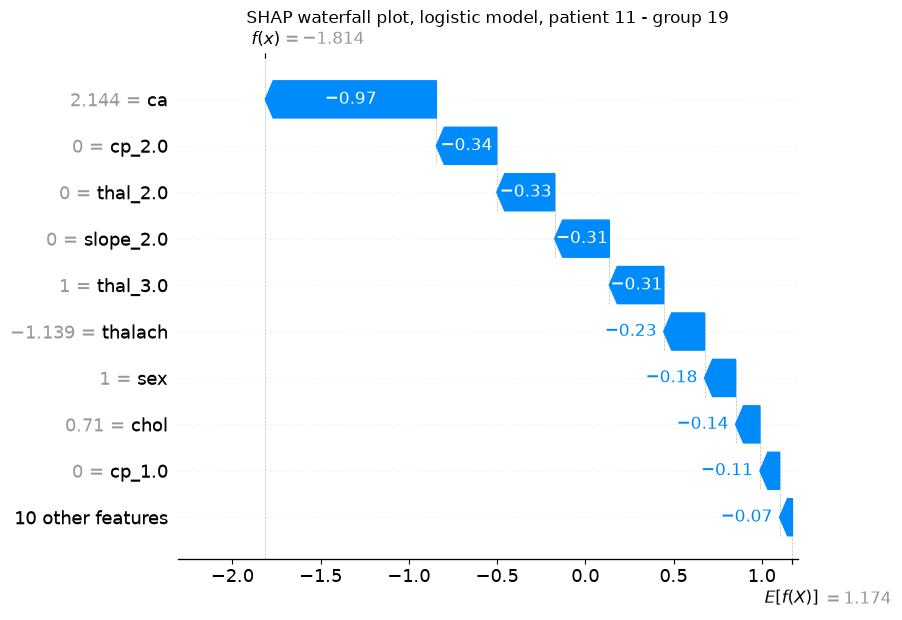

In [23]:
# (e) a patient whose most important attribute is not the globally most important one
abs_sv = pd.DataFrame(np.abs(sv.values), columns=sv.feature_names, index=X_test.index)
global_top = abs_sv.mean().idxmax()
local_top = abs_sv.idxmax(axis=1)
print("globally most important attribute:", global_top, f"(mean |SHAP| = {abs_sv.mean().max():.3f})")
print("\nmost important attribute per patient (number of patients):")
print(local_top.value_counts().to_string())
print(f"\n{(local_top != global_top).sum()} of {len(local_top)} test patients have another top attribute")

# take the patient where the globally top attribute matters least
others = abs_sv[local_top != global_top]
q = X_test.index.get_loc(others[global_top].idxmin())
print(f"\nexample: row {q} of the test set, top attribute {local_top.iloc[q]}")
print(pd.DataFrame({"x (original)": X_test.iloc[q]}).T.to_string())
print(f"SHAP {local_top.iloc[q]} = {sv.values[q][sv.feature_names.index(local_top.iloc[q])]:.3f},"
      f" SHAP {global_top} = {sv.values[q][sv.feature_names.index(global_top)]:.3f}"
      f" ({global_top} = {X_test.iloc[q][global_top]}, training mean {X_train[global_top].mean():.2f})")

shap.plots.waterfall(sv[q], max_display=10, show=False)
plt.title(f"SHAP waterfall plot, logistic model, patient {q} - group {GROUP_NUMBER}")
plt.show()

exact base value: 1.1739


,time (s),time per patient (s),base value,mean |difference|,max |difference|,correlation with exact,mean |change| vs smaller background
background,,,,,,,
10,0.7299,0.0365,1.3066,0.0444,0.2131,0.9783,NaN
50,1.1932,0.0597,1.0413,0.0149,0.0454,0.9984,0.0472
200,3.2696,0.1635,1.1490,0.0023,0.0259,0.9998,0.0159


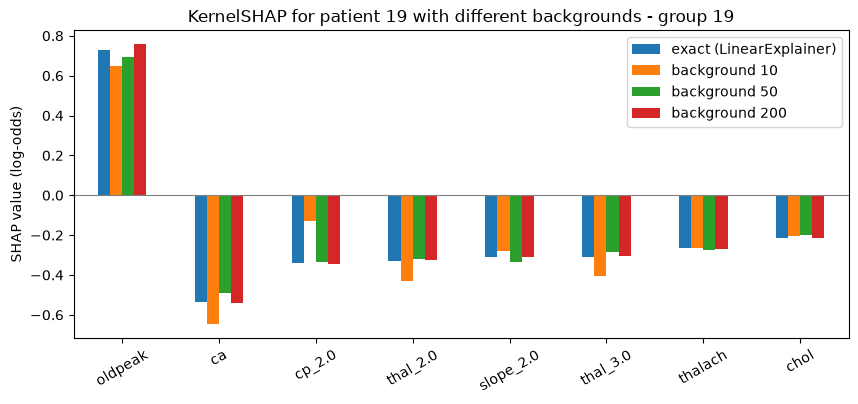

,exact (LinearExplainer),background 10,background 50,background 200
oldpeak,0.731,0.649,0.694,0.757
ca,-0.538,-0.648,-0.492,-0.542
cp_2.0,-0.342,-0.129,-0.336,-0.343
thal_2.0,-0.328,-0.430,-0.319,-0.326
slope_2.0,-0.310,-0.281,-0.337,-0.312
thal_3.0,-0.308,-0.406,-0.284,-0.307
thalach,-0.267,-0.265,-0.272,-0.268
chol,-0.217,-0.204,-0.198,-0.216


In [24]:
# (f) KernelSHAP with a background of 10, 50 and 200 patients (model output: log-odds).
# We explain the first 20 test patients (this includes our patient, row 19) and compare with the
# exact values of the LinearExplainer above, which uses the full training set as background.
# l1_reg=False: by default KernelSHAP keeps only the 10 strongest attributes and sets the rest to 0.
import time

f = lambda A: clf.decision_function(pd.DataFrame(A, columns=Xt_train.columns))
n_explain = 20
exact = sv.values[:n_explain]

kernel_rows, kernel_patient = [], {"exact (LinearExplainer)": pd.Series(sv.values[p], index=Xt_train.columns)}
for n_bg in [10, 50, 200]:
    background = shap.sample(Xt_train, n_bg, random_state=S)
    start = time.perf_counter()
    kernel = shap.KernelExplainer(f, background)
    values = kernel.shap_values(Xt_test.iloc[:n_explain], silent=True, l1_reg=False)
    seconds = time.perf_counter() - start
    diff = np.abs(values - exact)
    kernel_patient[f"background {n_bg}"] = pd.Series(values[p], index=Xt_train.columns)
    kernel_rows.append({"background": n_bg, "time (s)": seconds, "time per patient (s)": seconds / n_explain,
                        "base value": float(np.ravel(kernel.expected_value)[0]),
                        "mean |difference|": diff.mean(), "max |difference|": diff.max(),
                        "correlation with exact": np.corrcoef(values.ravel(), exact.ravel())[0, 1]})
    if n_bg > 10:
        change = np.abs(values - previous)
        kernel_rows[-1]["mean |change| vs smaller background"] = change.mean()
    previous = values

print("exact base value:", round(sv.base_values[p], 4))
display(pd.DataFrame(kernel_rows).set_index("background").round(4))

kernel_patient = pd.DataFrame(kernel_patient)
kernel_patient = kernel_patient.reindex(kernel_patient["exact (LinearExplainer)"].abs()
                                        .sort_values(ascending=False).index)
kernel_patient.head(8).plot.bar(figsize=(10, 4), rot=30)
plt.axhline(0, color="grey", lw=0.8)
plt.ylabel("SHAP value (log-odds)")
plt.title(f"KernelSHAP for patient {p} with different backgrounds - group {GROUP_NUMBER}")
plt.show()
kernel_patient.head(8).round(3)

**Your answers:**

a) Every dot is one test patient. The position on the x-axis is the SHAP value: how much this attribute moves the log-odds of this patient compared with the average patient. The colour is the value of the attribute (red = high). The attributes are sorted by their mean |SHAP|.

`oldpeak` is on top with the widest spread: patients with a low `oldpeak` (blue) are at about −0.97 and patients with a high one go up to +4.3, so a high `oldpeak` pushes the prediction strongly towards disease. The dummies form two groups. Patients with `cp` = 2 get +0.95 and all others −0.34. `ca` works the other way: `ca` = 0 gives +0.33 and `ca` = 3 gives −0.97. `slope_2` and `thal_2` push up when they are 1, `thal_3` and `sex` push down. `trestbps`, `fbs` and `restecg_2` stay around 0.

To compare with permutation importance we added the SHAP values of the dummies per attribute. The SHAP order is `oldpeak` (0.861), `cp` (0.554), `thal` (0.515), `slope` (0.426), `ca` (0.356), `sex` (0.234). Both methods put `oldpeak` first, but the rest of the accuracy-based permutation order is very different (`restecg`, `thalach`, `slope`, `exang`), with `cp`, `ca` and `thal` at ranks 10, 12 and 13. The Spearman correlation of the two rankings is −0.217. The reason is that SHAP measures how much the output of the model moves, and permutation importance measures how much the accuracy drops, which on 69 patients is mostly noise (6 of 13 values are negative). With ROC-AUC as score the permutation order is `oldpeak`, `cp`, `thal`, `slope`, `sex`, `ca`, and the correlation with SHAP is 0.973.

b) Every dot is a patient. The x-axis is the value of `exang` (0 or 1, with some jitter) and the y-axis is the SHAP value of `exang` for that patient. The colour is a second attribute that SHAP picks (`slope_1`), to show possible interactions. The grey bars are the histogram of `exang`.

There are only two levels: the 47 patients with `exang` = 0 get +0.1023 and the 22 patients with `exang` = 1 get −0.2091. The difference is −0.3114, which is β of `exang`. The values follow from β(x − mean) with mean 0.3284: −0.3114 · (0 − 0.3284) = +0.102 and −0.3114 · (1 − 0.3284) = −0.209. There is no vertical spread and the colour makes no difference, because a linear model has no interactions. In our data `exang` = 1 lowers the predicted risk, which is medically strange (see Lab 1).

A PDP shows the average prediction of the model if we set `exang` to a value for everybody, as one line on the scale of the output. The dependence plot shows one point per real patient, at the value the patient really has, and the y-axis is the contribution of `exang` relative to the average (centred at 0). If there are interactions, the points spread vertically, where a PDP only shows the average.

c) The waterfall plot starts at the bottom with the base value E[f(X)] = 1.174, the average log-odds over the training set (a probability of 0.764). Every bar is the SHAP value of one attribute, red pushes up and blue pushes down, and it ends at the top at f(x) = −0.734. For our patient only `oldpeak` = 1.8 (+0.731) and `age` = 46 (+0.214) push clearly towards disease. Many attributes push down: `ca` = 2 (−0.538), not having `cp` 2 (−0.342), not having `thal` 2 (−0.328), not having `slope` 2 (−0.310), `thal` = 3 (−0.308), low `thalach` (−0.267), high `chol` (−0.217), `exang` = 1 (−0.209) and being male (−0.176).

The force plot shows the same on one line: the red arrows push from the base value (1.17) to the right, the blue ones to the left, and they meet at f(x) = −0.73. The length of an arrow is the size of the SHAP value. The blue part is much longer than the red part.

Check: base value 1.1739 + sum of SHAP values (−1.9077) = −0.7338, and `decision_function` gives −0.7338. As a probability this is 0.3244, the same as `predict_proba` and as our hand calculation in Lab 1. The model predicts no disease, and the true label in our file is disease.

d) The table above has the numbers for all 19 columns. For example:
- `oldpeak`: 1.0780 · (0.6782 − 0) = 0.7310
- `ca`: −0.4523 · (1.1889 − 0) = −0.5377
- `cp_2`: 1.2936 · (0 − 0.2647) = −0.3424
- `exang`: −0.3114 · (1 − 0.3284) = −0.2091
- `sex`: −0.5349 · (1 − 0.6716) = −0.1757

These are the SHAP values. The largest difference over all 19 columns is 0.0, and the formula also holds for all 69 test patients. The mean is taken over the training set (the background). For the scaled attributes the mean is 0, so the SHAP value is just β·x, the same terms as in our hand calculation in Lab 1 (0.731, −0.538). For the dummies it is different: in Lab 1 the term of `cp_2` was 0, and here it is −0.342, because 26.5% of the training patients have `cp` 2 and our patient does not. SHAP compares with the average patient, the coefficients compare with the reference patient.

e) Globally `oldpeak` is the most important (mean |SHAP| 0.861), but for 32 of the 69 test patients another attribute is on top: `cp_2` 16 times, `ca` 7, `cp_1` 4, `slope_2` 3, `age` 1 and `chol` 1.

An example is row 11 of the test set, a 57-year-old man with `ca` = 3 and `oldpeak` = 1.0. His largest SHAP value is `ca` (−0.970), and `oldpeak` gives only −0.021, because his `oldpeak` is almost the training mean (1.02).

This is no contradiction. The global importance is an average of |SHAP| over all patients. A SHAP value is β(x − mean), so an attribute only matters for a patient whose value is far from the average. `oldpeak` is important on average because some patients have very high values, but for a patient with an average `oldpeak` it explains nothing, and then another attribute is on top.

f) We explained the first 20 test patients (with `l1_reg=False`, otherwise KernelSHAP sets all but 10 attributes to 0) and compared with the exact values.

| background | time | per patient | base value | mean \|difference\| with exact | max \|difference\| |
|---|---|---|---|---|---|
| 10 | 0.73 s | 0.04 s | 1.307 | 0.044 | 0.213 |
| 50 | 1.19 s | 0.06 s | 1.041 | 0.015 | 0.045 |
| 200 | 3.27 s | 0.16 s | 1.149 | 0.002 | 0.026 |

(exact base value: 1.174)

From 10 to 50 patients the SHAP values change by 0.047 on average, and from 50 to 200 by 0.016. With 10 background patients some values are clearly off. For our patient `cp_2` is −0.129 where the exact value is −0.342, and `oldpeak` is 0.649 where it should be 0.731. With 200 the values are almost exact (`oldpeak` 0.757, `cp_2` −0.343). SHAP values are relative to the average of the background, so a background of 10 patients has a different mean and a different base value (1.307), and a dummy like `cp_2` can have a very different share in such a small sample.

The time grows with the size of the background, because every sampled coalition is evaluated once for every background patient: 20 times more background takes about 4.5 times longer here. Our model is very cheap, so even 200 takes only 3 seconds, but for a slow model this is the main cost. The `LinearExplainer` gives the exact values right away, so for a logistic model KernelSHAP is not needed.

## Q4) Compare two models

a) **[Basic]** Derive the SHAP values for the random forest (code below). Together with your results from Q1 and Q2, compare and contrast the random forest with the logistic model. Which model is more sensitive to which attributes?

b) **[Regular]** Show the SHAP waterfall plot of your patient for both models. Which explanation would you show to a doctor? Why? Assess permutation importance, PDP and SHAP on completeness, comprehensibility and stability.

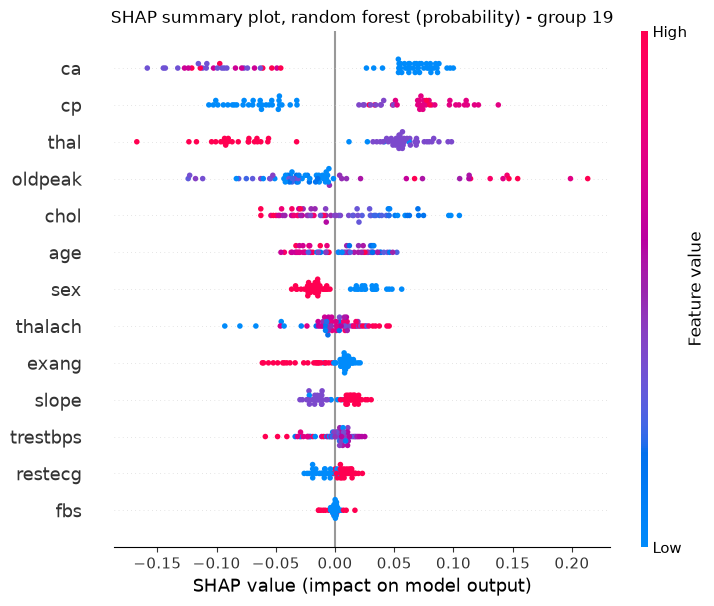

In [25]:
# SHAP for the random forest (exact and fast for trees)
explainer_rf = shap.TreeExplainer(rf)
sv_rf = explainer_rf(X_test)
if sv_rf.values.ndim == 3:       # one set of values per class: keep class 1 (heart disease)
    sv_rf = sv_rf[..., 1]

shap.plots.beeswarm(sv_rf, max_display=20, show=False)
plt.title(f"SHAP summary plot, random forest (probability) - group {GROUP_NUMBER}")
plt.show()

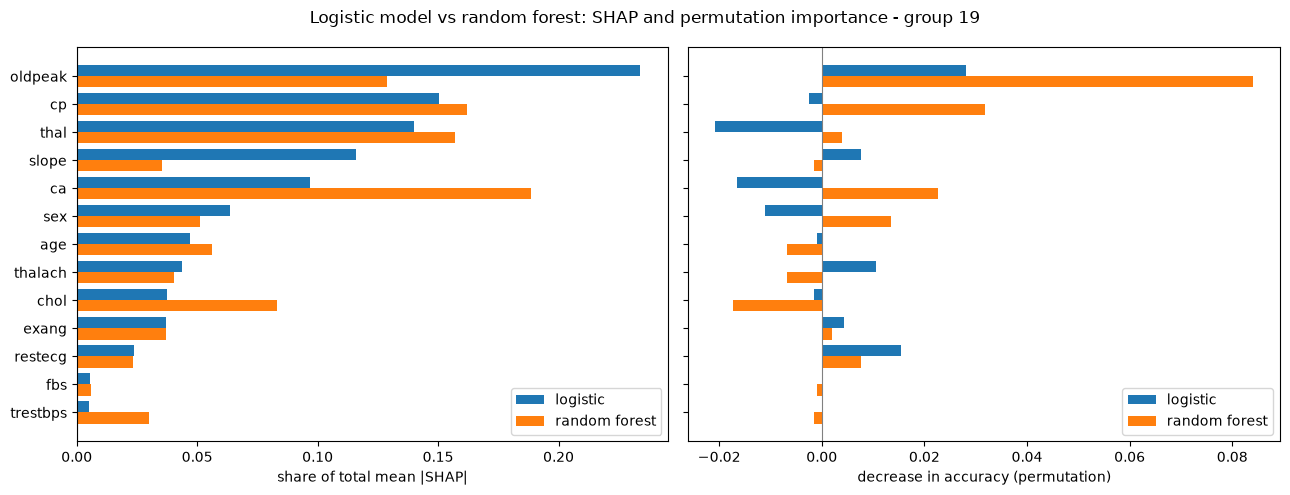

Spearman correlation of the SHAP rankings of the two models: 0.764


,perm logistic,perm forest,SHAP share logistic,SHAP share forest,rank SHAP logistic,rank SHAP forest
oldpeak,0.028,0.084,0.234,0.129,1,4
cp,-0.002,0.032,0.150,0.162,2,2
thal,-0.021,0.004,0.140,0.157,3,3
slope,0.008,-0.001,0.116,0.035,4,10
ca,-0.016,0.023,0.097,0.189,5,1
sex,-0.011,0.014,0.064,0.051,6,7
age,-0.001,-0.007,0.047,0.056,7,6
thalach,0.011,-0.007,0.044,0.041,8,8
chol,-0.001,-0.017,0.038,0.083,9,5
exang,0.004,0.002,0.037,0.037,10,9


In [26]:
# (a) logistic model vs random forest: permutation importance and mean |SHAP| per attribute.
# The SHAP values of the logistic model are on the log-odds scale and those of the forest on the
# probability scale, so we compare the share of each attribute in the total, and the ranks.
shap_lr = sv_attr.abs().mean()
shap_rf = pd.Series(np.abs(sv_rf.values).mean(axis=0), index=X_test.columns)
both = pd.DataFrame({"perm logistic": perm_mean["logistic"], "perm forest": perm_mean["random forest"],
                     "SHAP share logistic": shap_lr / shap_lr.sum(),
                     "SHAP share forest": shap_rf / shap_rf.sum()})
both["rank SHAP logistic"] = both["SHAP share logistic"].rank(ascending=False).astype(int)
both["rank SHAP forest"] = both["SHAP share forest"].rank(ascending=False).astype(int)
both = both.sort_values("SHAP share logistic", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order = both.index[::-1]
pos = np.arange(len(order))
for ax, cols, xlabel in [(axes[0], ["SHAP share logistic", "SHAP share forest"], "share of total mean |SHAP|"),
                         (axes[1], ["perm logistic", "perm forest"], "decrease in accuracy (permutation)")]:
    ax.barh(pos + 0.2, both.loc[order, cols[0]], height=0.4, label="logistic")
    ax.barh(pos - 0.2, both.loc[order, cols[1]], height=0.4, label="random forest")
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_yticks(pos, order)
    ax.set_xlabel(xlabel)
    ax.legend()
fig.suptitle(f"Logistic model vs random forest: SHAP and permutation importance - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

print("Spearman correlation of the SHAP rankings of the two models:",
      round(both["SHAP share logistic"].corr(both["SHAP share forest"], method="spearman"), 3))
both.round(3)

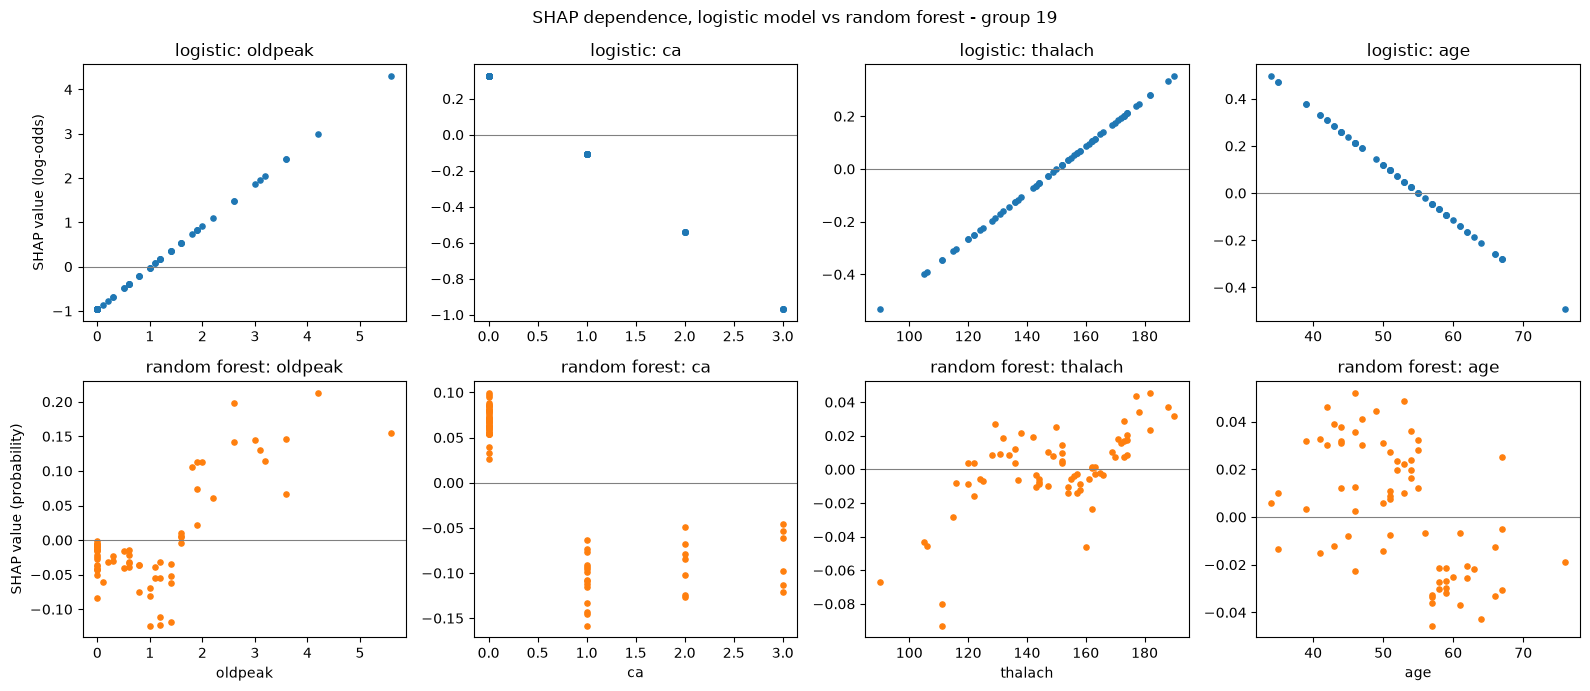

In [27]:
# (a) how the two models use their most important attributes: SHAP dependence, forest next to logistic
top_attrs = ["oldpeak", "ca", "thalach", "age"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, a in enumerate(top_attrs):
    axes[0, j].scatter(X_test[a], sv_attr[a], s=14, color="tab:blue")
    axes[0, j].set_title(f"logistic: {a}")
    axes[1, j].scatter(X_test[a], sv_rf[:, a].values, s=14, color="tab:orange")
    axes[1, j].set_title(f"random forest: {a}")
    axes[1, j].set_xlabel(a)
    for ax in axes[:, j]:
        ax.axhline(0, color="grey", lw=0.8)
axes[0, 0].set_ylabel("SHAP value (log-odds)")
axes[1, 0].set_ylabel("SHAP value (probability)")
fig.suptitle(f"SHAP dependence, logistic model vs random forest - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

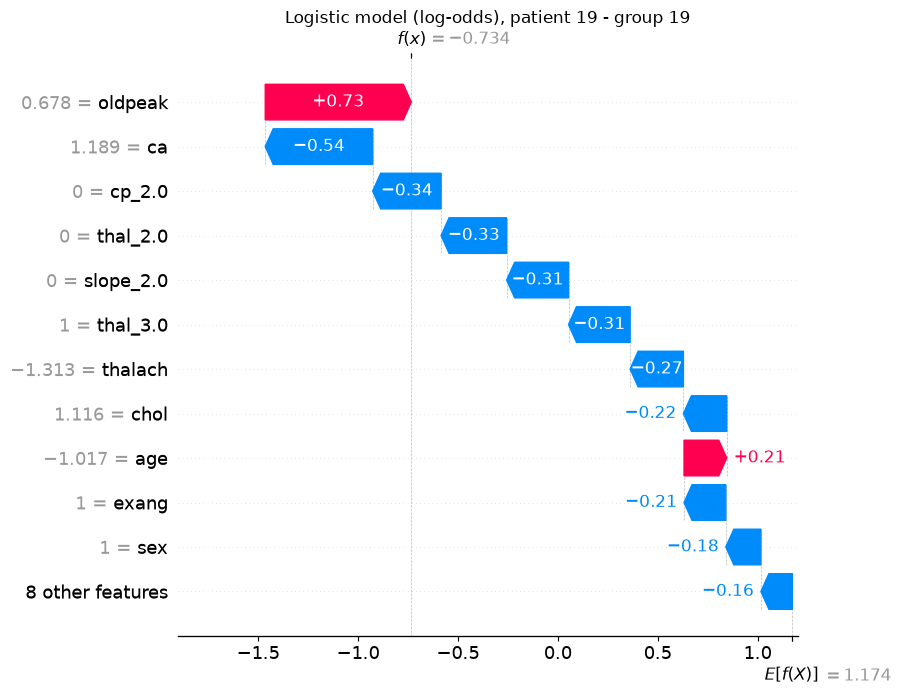

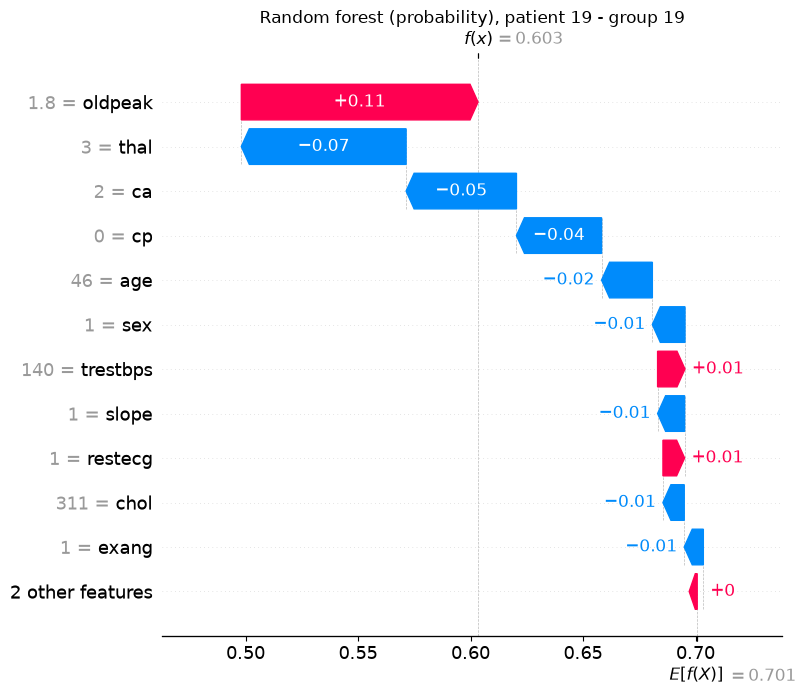

logistic: base 1.174 + -1.908 = -0.734 log-odds -> P(disease) = 0.324
forest:   base 0.701 + -0.097 = 0.603 -> P(disease) = 0.603
true label of our patient: 1


,value,SHAP logistic (log-odds),SHAP forest (probability),same direction
oldpeak,1.8,0.731,0.105,True
thal,3.0,-0.662,-0.073,True
ca,2.0,-0.538,-0.049,True
cp,0.0,-0.466,-0.038,True
age,46.0,0.214,-0.023,False
sex,1.0,-0.176,-0.015,True
trestbps,140.0,0.013,0.012,True
slope,1.0,-0.399,-0.012,True
restecg,1.0,0.079,0.010,True
chol,311.0,-0.217,-0.009,True


In [28]:
# (b) waterfall plot of our patient for both models
shap.plots.waterfall(sv[p], max_display=12, show=False)
plt.title(f"Logistic model (log-odds), patient {p} - group {GROUP_NUMBER}")
plt.show()

shap.plots.waterfall(sv_rf[p], max_display=12, show=False)
plt.title(f"Random forest (probability), patient {p} - group {GROUP_NUMBER}")
plt.show()

print(f"logistic: base {sv.base_values[p]:.3f} + {sv.values[p].sum():.3f} = "
      f"{sv.base_values[p] + sv.values[p].sum():.3f} log-odds -> P(disease) = {logreg.predict_proba(x_p)[0, 1]:.3f}")
print(f"forest:   base {sv_rf.base_values[p]:.3f} + {sv_rf.values[p].sum():.3f} = "
      f"{sv_rf.base_values[p] + sv_rf.values[p].sum():.3f} -> P(disease) = {rf.predict_proba(x_p)[0, 1]:.3f}")
print("true label of our patient:", y_test.iloc[p])

patient = pd.DataFrame({"value": x_p.iloc[0],
                        "SHAP logistic (log-odds)": sv_attr.iloc[p],
                        "SHAP forest (probability)": pd.Series(sv_rf.values[p], index=X_test.columns)})
patient["same direction"] = np.sign(patient.iloc[:, 1]) == np.sign(patient.iloc[:, 2])
patient.reindex(patient["SHAP forest (probability)"].abs().sort_values(ascending=False).index).round(3)

In [29]:
# (b) stability: do the explanations change when the model is trained on another bootstrap sample?
# Five random forests on bootstrap samples of the training set (seeds S, ..., S+4).
from sklearn.utils import resample

stab = {"permutation": [], "SHAP": [], "PDP oldpeak": []}
patient_shap = []
grid_old = np.linspace(X_test["oldpeak"].min(), X_test["oldpeak"].max(), 20)
for i in range(5):
    Xb, yb = resample(X_train, y_train, random_state=S + i)
    m = RandomForestClassifier(n_estimators=300, random_state=S).fit(Xb, yb)
    r_b = permutation_importance(m, X_test, y_test, n_repeats=30, random_state=S)
    stab["permutation"].append(pd.Series(r_b.importances_mean, index=X_test.columns))
    e = shap.TreeExplainer(m)(X_test)
    e = e[..., 1] if e.values.ndim == 3 else e
    stab["SHAP"].append(pd.Series(np.abs(e.values).mean(axis=0), index=X_test.columns))
    patient_shap.append(pd.Series(e.values[p], index=X_test.columns))
    stab["PDP oldpeak"].append(ice_curves(m, X_test, "oldpeak", grid_old).mean())

for key in ["permutation", "SHAP"]:
    t = pd.DataFrame(stab[key]).T
    tops = [", ".join(t[c].nlargest(3).index) for c in t]
    corrs = t.corr(method="spearman").values[np.triu_indices(5, 1)]
    print(f"{key:12s} top 3 per forest: {tops}")
    print(f"{'':12s} mean Spearman correlation between the 5 rankings: {corrs.mean():.3f}")
pdp_b = pd.DataFrame(stab["PDP oldpeak"]).T
print(f"PDP oldpeak  mean correlation between the 5 curves: "
      f"{pdp_b.corr().values[np.triu_indices(5, 1)].mean():.3f},"
      f" largest gap between two curves: {(pdp_b.max(axis=1) - pdp_b.min(axis=1)).max():.3f}")
ps = pd.DataFrame(patient_shap).T
print("\nSHAP values of our patient in the 5 forests (top 5 attributes of the original forest):")
ps.loc[patient["SHAP forest (probability)"].abs().nlargest(5).index].round(3)

permutation  top 3 per forest: ['ca, oldpeak, cp', 'oldpeak, ca, thal', 'oldpeak, cp, ca', 'oldpeak, cp, ca', 'oldpeak, age, cp']
             mean Spearman correlation between the 5 rankings: 0.604
SHAP         top 3 per forest: ['ca, oldpeak, thal', 'thal, ca, cp', 'ca, oldpeak, cp', 'thal, oldpeak, cp', 'thal, ca, cp']
             mean Spearman correlation between the 5 rankings: 0.870
PDP oldpeak  mean correlation between the 5 curves: 0.960, largest gap between two curves: 0.091

SHAP values of our patient in the 5 forests (top 5 attributes of the original forest):


,0,1,2,3,4
oldpeak,0.055,0.080,0.138,0.196,0.089
thal,-0.045,-0.071,-0.055,-0.085,-0.087
ca,-0.065,-0.036,-0.067,-0.022,0.001
cp,-0.003,-0.024,-0.040,-0.024,-0.021
age,0.014,-0.037,-0.009,-0.007,-0.035


**Your answers:**

a) The SHAP values of the logistic model are in log-odds and those of the forest in probability, so we compare the share of each attribute in the total mean |SHAP|.

| | logistic | random forest |
|---|---|---|
| test accuracy / ROC-AUC | 0.754 / 0.817 | 0.812 / 0.829 |
| SHAP rank 1 | `oldpeak` (23.4%) | `ca` (18.9%) |
| SHAP rank 2 | `cp` (15.0%) | `cp` (16.2%) |
| SHAP rank 3 | `thal` (14.0%) | `thal` (15.7%) |
| SHAP rank 4 | `slope` (11.6%) | `oldpeak` (12.9%) |
| SHAP rank 5 | `ca` (9.7%) | `chol` (8.3%) |

The two models mostly agree: the Spearman correlation of the two rankings is 0.764, and `oldpeak`, `cp`, `thal` and `ca` are in the top 5 of both. The logistic model is more sensitive to `oldpeak` (23.4% against 12.9%) and to `slope` (rank 4 against rank 10). The forest is more sensitive to `ca` (18.9% against 9.7%), `chol` (8.3% against 3.8%) and `trestbps` (3.0% against 0.5%). In Q1c we saw that `chol` only helps the forest on the training set, so this is partly overfitting.

Permutation importance gives a different picture of `oldpeak`: shuffling it costs the forest 0.084 accuracy and the logistic model only 0.028. So the forest needs `oldpeak` more to get its predictions right, even though its share of the SHAP values is smaller.

The largest difference is in how the attributes are used (PDP in Q2, SHAP dependence above). In the logistic model every effect is a straight line: every unit of `oldpeak` adds 0.94 to the log-odds, so the SHAP values run from −0.97 to +4.3 and patients with an extreme `oldpeak` get an extreme prediction. The forest uses thresholds: the SHAP value of `oldpeak` is negative (down to −0.12) below about 1.5, turns positive around 1.6 and stays around +0.1 to +0.2. For `ca` the logistic model goes down in equal steps (+0.33 at 0 to −0.97 at 3), and the forest only separates `ca` = 0 (+0.03 to +0.10) from 1 or more (−0.05 to −0.16). For `age` the forest has a step around 55 where the logistic model has a line. In the forest patients with the same value get different SHAP values (vertical spread), so it has interactions. The logistic model has none.

b) The logistic model starts at 1.174 and ends at −0.734 log-odds (P = 0.324, no disease). The forest starts at 0.701 and ends at 0.603 (disease). The label in our file is disease, so the forest is right and the logistic model is wrong.

The two explanations agree on the direction of 11 of the 13 attributes. In both, `oldpeak` = 1.8 is the main reason for disease (+0.731 log-odds, +0.105 probability), and `thal` = 3 (−0.662, −0.073), `ca` = 2 (−0.538, −0.049) and `cp` = 0 (−0.466, −0.038) are the main reasons against. They disagree on `age` (+0.214 against −0.023) and `thalach` (−0.267 against +0.004). In the logistic model many middle-sized negative terms (`slope` −0.399, `thalach` −0.267, `chol` −0.217, `exang` −0.209, `sex` −0.176) add up and pull the patient below 0.5. In the forest these are all 0.015 or smaller.

We would show the doctor the waterfall of the random forest, for three reasons. It is in probability (from 70% for an average patient down to 60%), and log-odds are hard to read. It uses the original attributes and values (`oldpeak` = 1.8, `ca` = 2), where the logistic plot shows scaled values and dummies ("`cp_2.0` = 0 gives −0.34", and two bars for the one fact that `thal` = 3). And the forest is the better model and is right for this patient. We would only show the top 4 or 5 bars. We would also say that the plot explains the model and not the disease, and that it is less stable than it looks: over five forests trained on bootstrap samples the SHAP value of `oldpeak` for our patient is between 0.055 and 0.196, and `ca` between −0.067 and +0.001.

| | permutation importance | PDP (+ ICE) | SHAP |
|---|---|---|---|
| **Completeness** | Low. One number per attribute for the whole model. No direction, nothing about one patient, and the numbers do not add up to the prediction. Correlated attributes share their importance (`thalach` 0.0106 → 0.0010 with a copy). | Medium. Shows the whole shape of an effect, but for one or two attributes at a time and as an average. It hides patients who go the other way (tree, `oldpeak`: +0.087 on average, but 10 up and 4 down) unless ICE curves are added. | High for one prediction. Base value + SHAP values is exactly the output (1.174 − 1.908 = −0.734, and 0.701 − 0.097 = 0.603). Also gives a global picture (beeswarm). |
| **Comprehensibility** | The easiest: "how much worse does the model get without this attribute". | Easy: a curve in the original units. It is tempting to read it as cause and effect. | The hardest: base value, log-odds, "compared with the average patient", dummies. But the waterfall is the only plot that answers "why this patient". |
| **Stability** | Poor on our 69 test patients: the standard deviation is as large as the value (`oldpeak` 0.028 ± 0.027), 6 of 13 values are negative, and the rankings of five bootstrap forests have a mean Spearman correlation of 0.604. | The best: the `oldpeak` curves of the five forests have a mean correlation of 0.960 and differ at most 0.091. | In between. Global rankings: 0.870 between the five forests, but the top attribute changes between `ca` and `thal`. Values for one patient vary a lot. KernelSHAP also depends on the background (Q3f). For the logistic model the values are exact. |

## Q5) Find the hidden change

a) **[Advanced]** The data of your group has one hidden change compared to the original data set (`data/heart_original.csv`). For example, the effect of one attribute was made stronger, or one attribute was made to depend on another one. Use the methods of this lab on both data sets to find the change. Which attribute(s) were changed, and what kind of change is it? Show the plots that support your answer. Which method was most useful, and which one did not show the change?

In [30]:
original = pd.read_csv("data/heart_original.csv", sep=",", header=0, decimal=".")  # same arguments as for our own file
print("our file:", df.shape, "- original:", original.shape)
print("share of target = 1: our file", round(df["target"].mean(), 3), "- original", round(original["target"].mean(), 3))


def fit_all(data):
    """Same split, preprocessing and models as above, for another data set."""
    Xd = data.drop(columns="target").astype(float)
    yd = data["target"]
    Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, stratify=yd, random_state=S)
    lr = make_pipeline(clone(preprocessor), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
    forest = RandomForestClassifier(n_estimators=300, random_state=S).fit(Xtr, ytr)
    return {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte, "logistic": lr, "random forest": forest}


data_sets = {"our data (group 19)": {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test,
                                     "logistic": logreg, "random forest": rf},
             "original data": fit_all(original)}
pd.DataFrame({ds: {f"{m} test accuracy": d[m].score(d["X_test"], d["y_test"]) for m in ["logistic", "random forest"]}
              for ds, d in data_sets.items()}).round(3)

our file: (273, 14) - original: (303, 14)
share of target = 1: our file 0.703 - original 0.545


,our data (group 19),original data
logistic test accuracy,0.754,0.868
random forest test accuracy,0.812,0.882


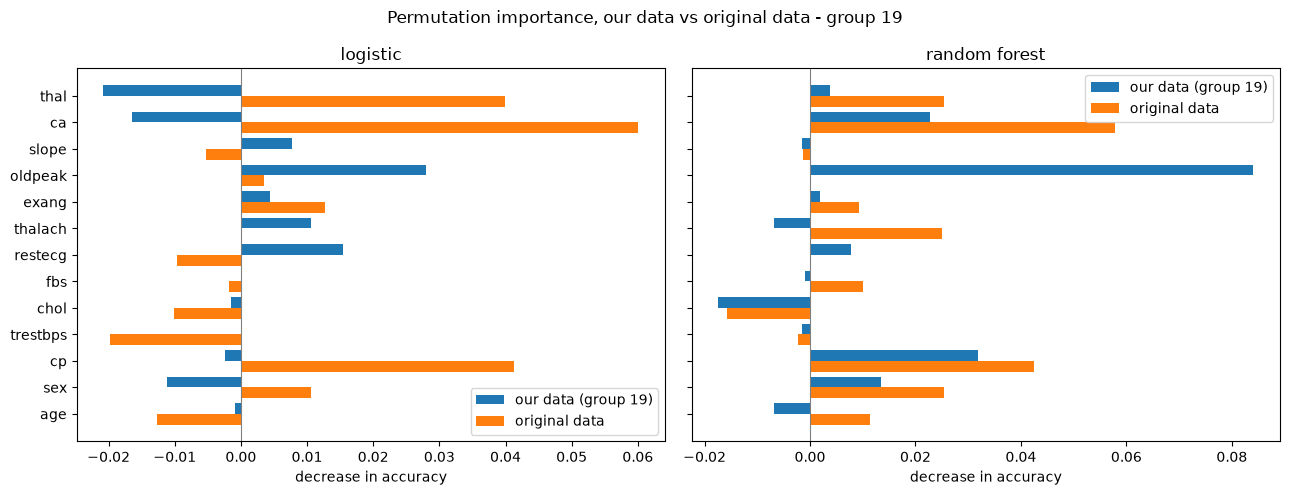

importance                                                  \
                    logistic       random forest      logistic random forest   
         our data (group 19) our data (group 19) original data original data   
age                   -0.001              -0.007        -0.013         0.011   
sex                   -0.011               0.014         0.011         0.025   
cp                    -0.002               0.032         0.041         0.043   
trestbps               0.000              -0.001        -0.020        -0.002   
chol                  -0.001              -0.017        -0.010        -0.016   
fbs                    0.000              -0.001        -0.002         0.010   
restecg                0.015               0.008        -0.010        -0.000   
thalach                0.011              -0.007         0.000         0.025   
exang                  0.004               0.002         0.013         0.009   
oldpeak                0.028               0.084         0.004        -0.000   
slope                  0.008              -0.001        -0.005        -0.001   
ca                    -0.016               0.023         0.060         0.058   
thal                  -0.021               0.004         0.040         0.025   

                        rank                                                  
                    logistic       random forest      logistic random forest  
         our data (group 19) our data (group 19) original data original data  
age                        8                  12            12             6  
sex                       11                   4             5             3  
cp                        10                   2             2             2  
trestbps                   6                  10            13            12  
chol                       9                  13            11            13  
fbs                        6                   8             8             7  
restecg                    2                   5            10             9  
thalach                    3                  11             7             5  
exang                      5                   7             4             8  
oldpeak                    1                   1             6            10  
slope                      4                   9             9            11  
ca                        12                   3             1             1  
thal                      13                   6             3             4

In [31]:
# Step 1: permutation importance on both data sets
perm5 = {}
for ds, d in data_sets.items():
    for m in ["logistic", "random forest"]:
        r5 = permutation_importance(d[m], d["X_test"], d["y_test"], n_repeats=30, random_state=S)
        perm5[(m, ds)] = pd.Series(r5.importances_mean, index=d["X_test"].columns)
perm5 = pd.DataFrame(perm5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
pos = np.arange(len(perm5))
for ax, m in zip(axes, ["logistic", "random forest"]):
    ax.barh(pos + 0.2, perm5[(m, "our data (group 19)")], height=0.4, label="our data (group 19)")
    ax.barh(pos - 0.2, perm5[(m, "original data")], height=0.4, label="original data")
    ax.set_yticks(pos, perm5.index)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_xlabel("decrease in accuracy")
    ax.set_title(m)
    ax.legend()
fig.suptitle(f"Permutation importance, our data vs original data - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

rank5 = perm5.rank(ascending=False).astype(int)
pd.concat({"importance": perm5.round(3), "rank": rank5}, axis=1)

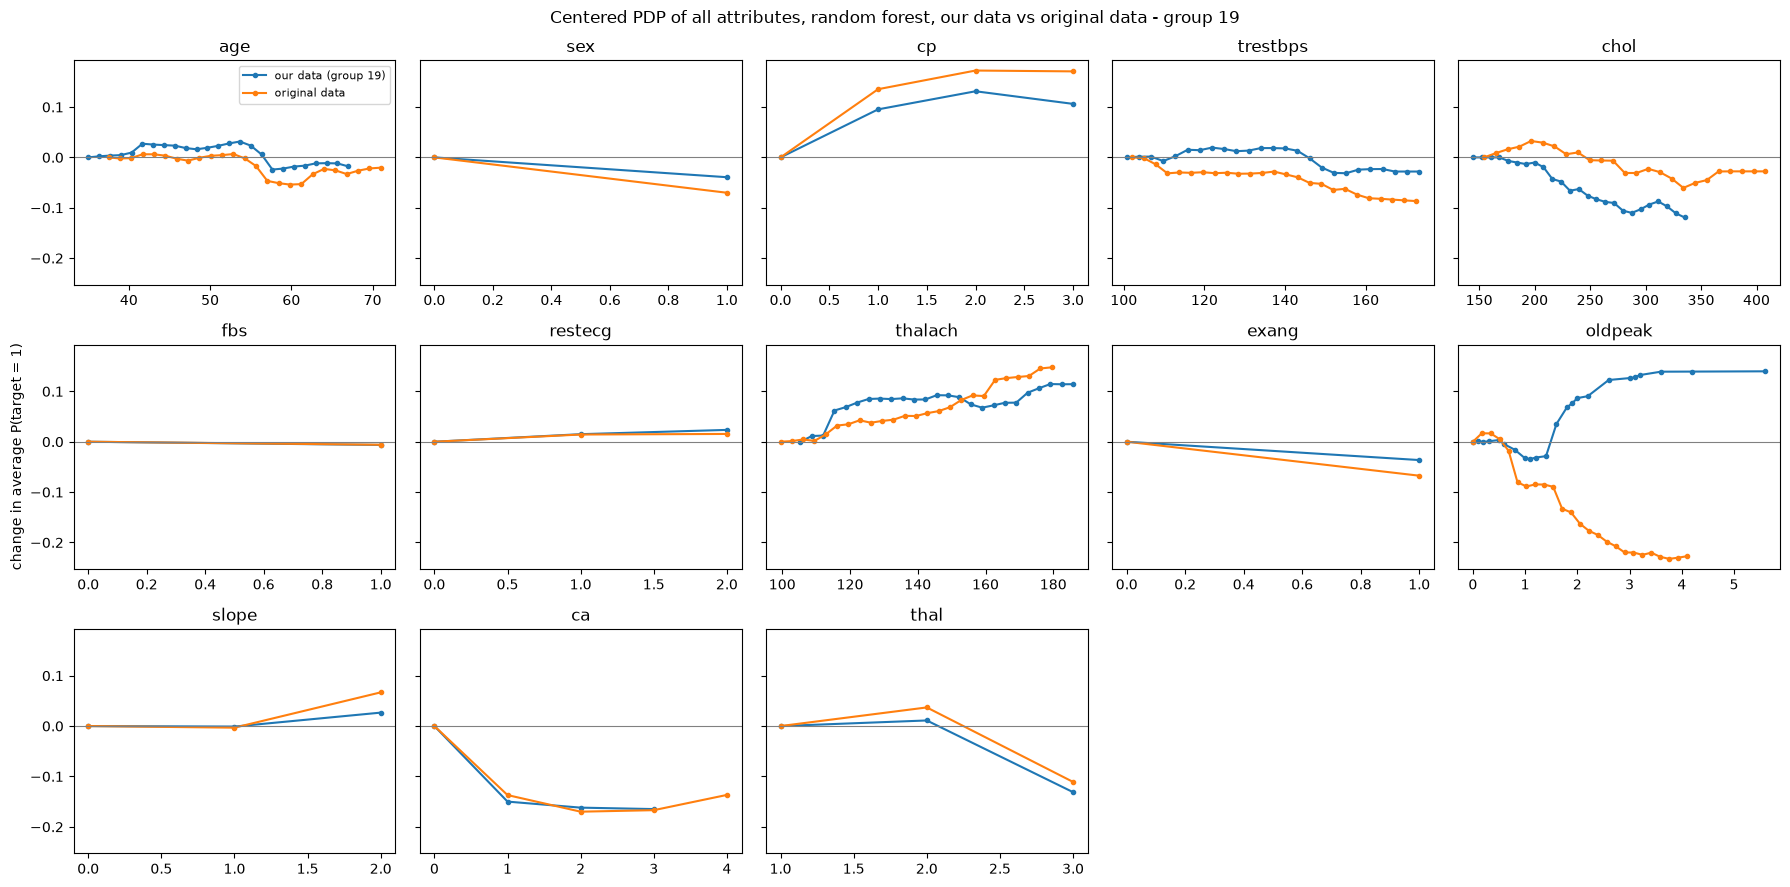

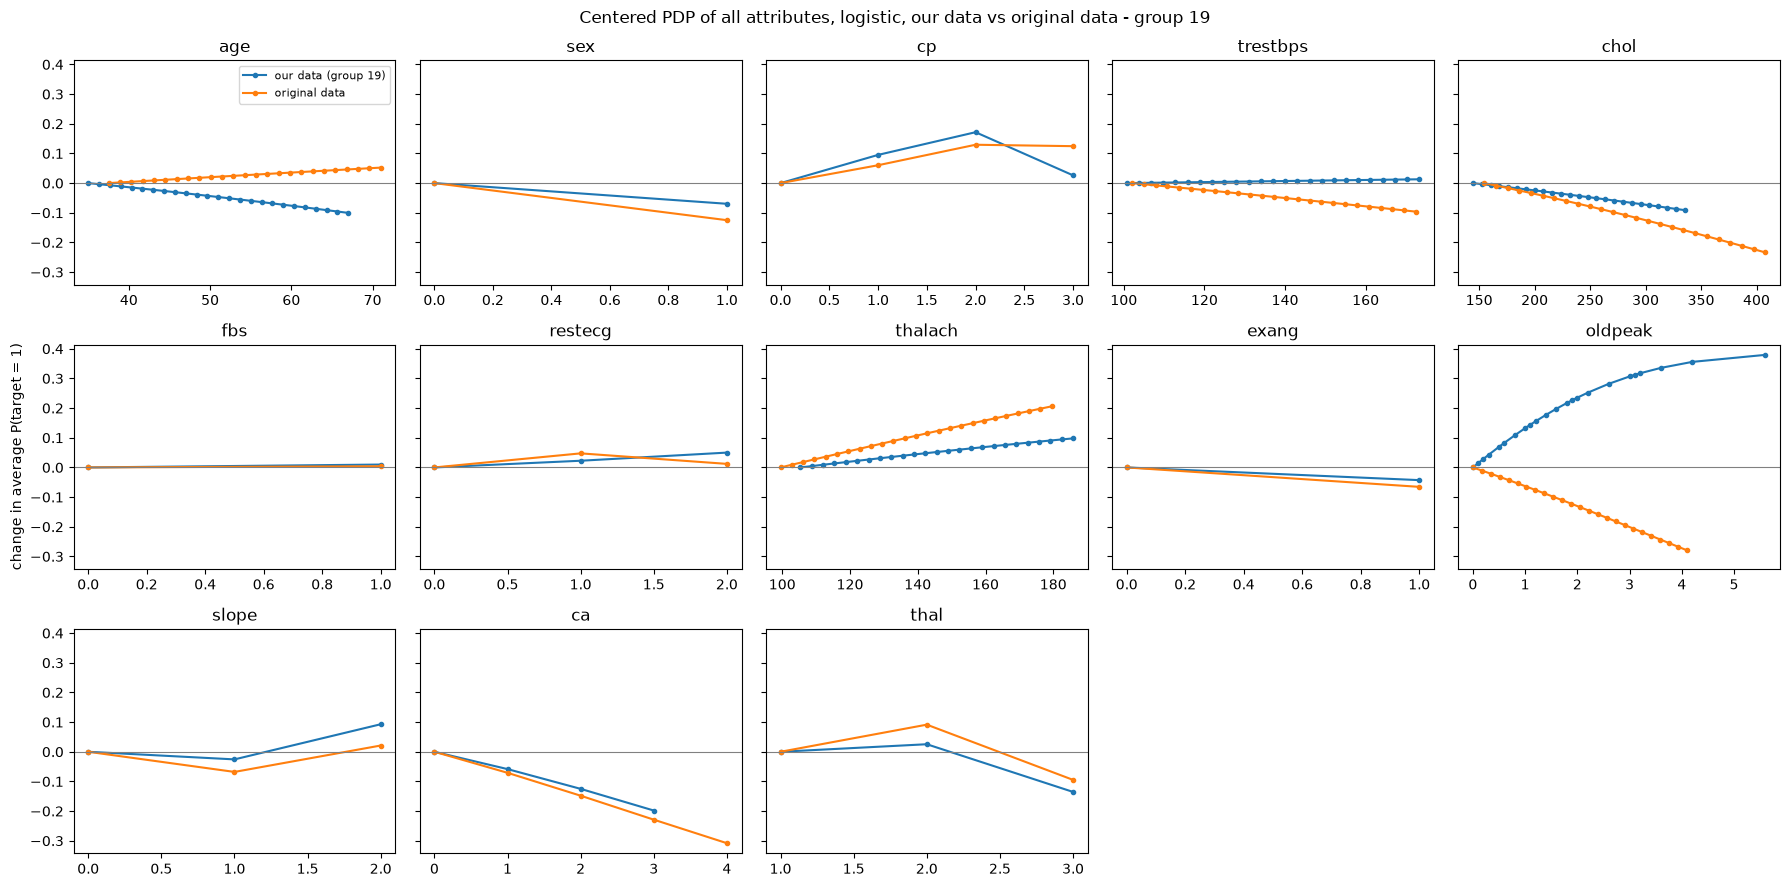

logistic                                   random forest  \
         difference original data our data (group 19)    difference   
age          -0.153         0.052              -0.100         0.003   
sex           0.055        -0.125              -0.070         0.031   
cp           -0.098         0.125               0.026        -0.065   
trestbps      0.109        -0.096               0.013         0.059   
chol          0.143        -0.234              -0.091        -0.092   
fbs           0.006         0.004               0.010        -0.000   
restecg       0.038         0.012               0.050         0.008   
thalach      -0.108         0.206               0.098        -0.033   
exang         0.023        -0.065              -0.043         0.031   
oldpeak       0.659        -0.279               0.379         0.367   
slope         0.072         0.021               0.093        -0.040   
ca            0.110        -0.308              -0.198        -0.028   
thal         -0.041        -0.095              -0.135        -0.020   

                                            
         original data our data (group 19)  
age             -0.020              -0.018  
sex             -0.070              -0.039  
cp               0.171               0.106  
trestbps        -0.087              -0.028  
chol            -0.028              -0.119  
fbs             -0.006              -0.006  
restecg          0.015               0.023  
thalach          0.148               0.114  
exang           -0.067              -0.036  
oldpeak         -0.227               0.140  
slope            0.067               0.027  
ca              -0.137              -0.165  
thal            -0.111              -0.131

In [32]:
# Step 2: PDP of every attribute on both data sets (random forest and logistic model)
def pdp_curve(model, X_part, feature):
    grid = np.sort(X_part[feature].unique())
    if len(grid) > 25:
        grid = np.linspace(X_part[feature].quantile(0.02), X_part[feature].quantile(0.98), 25)
    return ice_curves(model, X_part, feature, grid).mean()


pdp_change = {}
for m in ["random forest", "logistic"]:
    fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharey=True)
    for ax, feature in zip(axes.ravel(), X.columns):
        for ds, d in data_sets.items():
            curve = pdp_curve(d[m], d["X_test"], feature)
            centered = curve - curve.iloc[0]
            pdp_change[(m, ds, feature)] = centered.iloc[-1]
            ax.plot(centered.index, centered.values, marker=".", label=ds)
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_title(feature)
    for ax in axes.ravel()[len(X.columns):]:
        ax.axis("off")
    axes[0, 0].legend(fontsize=8)
    axes[1, 0].set_ylabel("change in average P(target = 1)")
    fig.suptitle(f"Centered PDP of all attributes, {m}, our data vs original data - group {GROUP_NUMBER}")
    plt.tight_layout()
    plt.show()

# change of the PDP from the lowest to the highest value of each attribute
pdp_change = pd.Series(pdp_change).unstack([0, 1]).reindex(X.columns)
for m in ["random forest", "logistic"]:
    pdp_change[(m, "difference")] = pdp_change[(m, "our data (group 19)")] - pdp_change[(m, "original data")]
pdp_change.sort_index(axis=1).round(3)

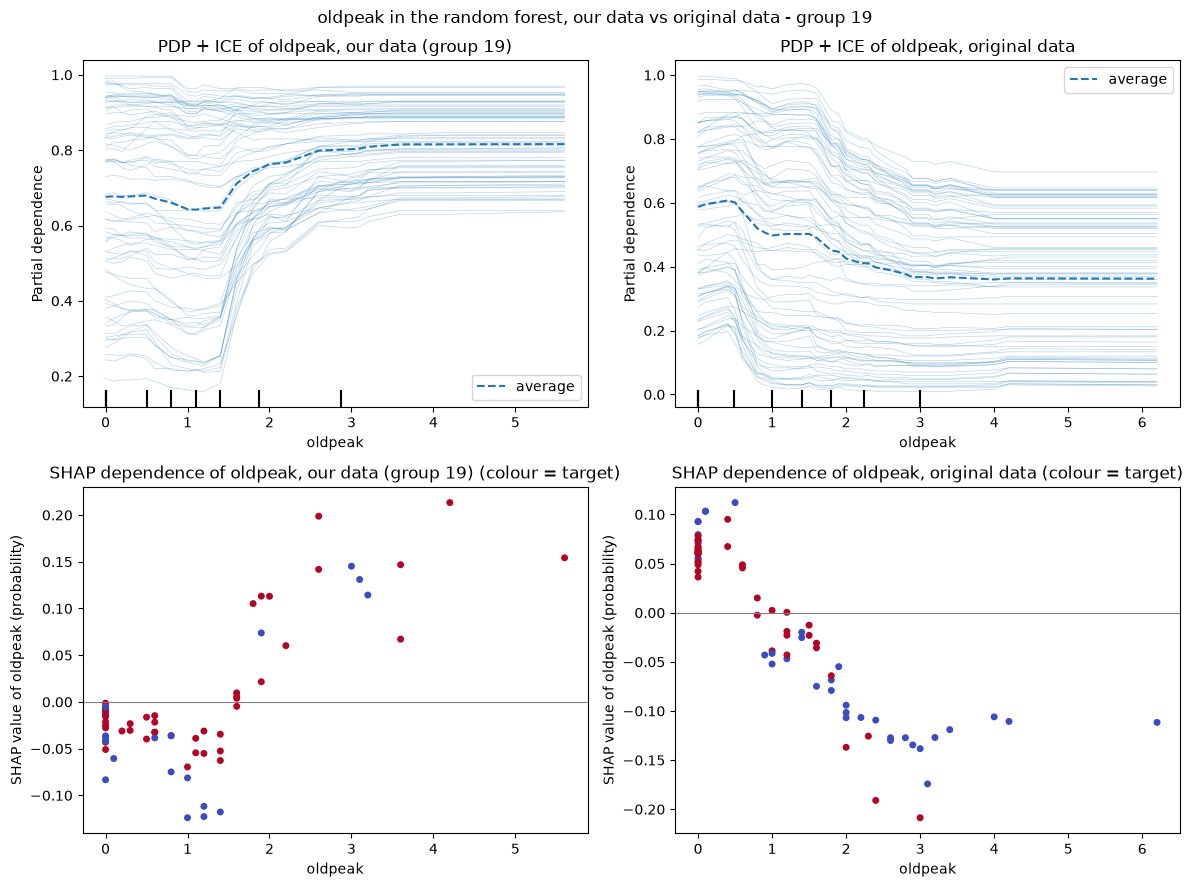

our data (group 19)                   original data                  
                 mean |SHAP| corr(value, SHAP)   mean |SHAP| corr(value, SHAP)
age                    0.024            -0.515         0.023            -0.582
sex                    0.022            -0.933         0.035            -0.968
cp                     0.069             0.900         0.095             0.903
trestbps               0.013            -0.340         0.014            -0.722
chol                   0.035            -0.861         0.026            -0.638
fbs                    0.003            -0.228         0.002            -0.019
restecg                0.010             0.801         0.008             0.822
thalach                0.017             0.634         0.047             0.922
exang                  0.016            -0.842         0.039            -0.972
oldpeak                0.055             0.717         0.074            -0.873
slope                  0.015             0.783         0.042             0.852
ca                     0.080            -0.776         0.088            -0.835
thal                   0.067            -0.840         0.074            -0.892

standardised beta of the numerical attributes in the logistic model:


,our data (group 19),original data
age,-0.210,0.126
trestbps,0.023,-0.215
chol,-0.194,-0.355
thalach,0.203,0.487
oldpeak,1.078,-0.567
ca,-0.452,-0.610


In [33]:
# Step 3: a closer look at oldpeak with PDP + ICE and with SHAP (random forest)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for j, (ds, d) in enumerate(data_sets.items()):
    PartialDependenceDisplay.from_estimator(d["random forest"], d["X_test"], ["oldpeak"], kind="both",
                                            random_state=S, ax=axes[0, j])
    axes[0, j].set_title(f"PDP + ICE of oldpeak, {ds}")

    e = shap.TreeExplainer(d["random forest"])(d["X_test"])
    e = e[..., 1] if e.values.ndim == 3 else e
    d["shap_rf"] = e
    axes[1, j].scatter(d["X_test"]["oldpeak"], e[:, "oldpeak"].values, s=16, c=d["y_test"], cmap="coolwarm")
    axes[1, j].axhline(0, color="grey", lw=0.8)
    axes[1, j].set_xlabel("oldpeak")
    axes[1, j].set_ylabel("SHAP value of oldpeak (probability)")
    axes[1, j].set_title(f"SHAP dependence of oldpeak, {ds} (colour = target)")
fig.suptitle(f"oldpeak in the random forest, our data vs original data - group {GROUP_NUMBER}")
plt.tight_layout()
plt.show()

# SHAP: global importance and direction of every attribute on both data sets
shap5 = {}
for ds, d in data_sets.items():
    e = d["shap_rf"]
    shap5[(ds, "mean |SHAP|")] = pd.Series(np.abs(e.values).mean(axis=0), index=X.columns)
    shap5[(ds, "corr(value, SHAP)")] = pd.Series(
        [np.corrcoef(d["X_test"][c], e[:, c].values)[0, 1] for c in X.columns], index=X.columns)
    lr_d, pre_d = d["logistic"][-1], d["logistic"][:-1]
    d["beta"] = pd.Series(lr_d.coef_[0], index=pre_d.get_feature_names_out())
display(pd.DataFrame(shap5).round(3))

print("standardised beta of the numerical attributes in the logistic model:")
pd.DataFrame({ds: d["beta"][num_cols] for ds, d in data_sets.items()}).round(3)

patients of our file found in the original: 273 of 273
attribute values changed: 0 (the match is on all 13 attributes) - labels changed: 42

original label (rows) vs our label (columns):
target            0    1
target_original         
0                81   42
1                 0  150

smallest oldpeak of a changed patient: 1.6


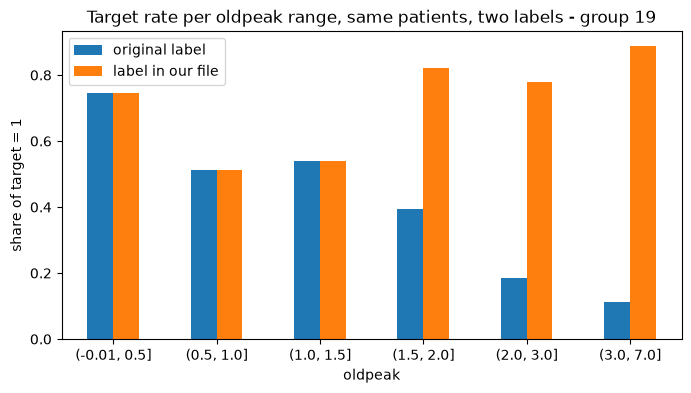

,patients,original_rate,our_rate,labels_changed,original label 0,share of label 0 changed
oldpeak,,,,,,
"(-0.01, 0.5]",122,0.746,0.746,0,31,0.000
"(0.5, 1.0]",41,0.512,0.512,0,20,0.000
"(1.0, 1.5]",37,0.541,0.541,0,17,0.000
"(1.5, 2.0]",28,0.393,0.821,12,17,0.706
"(2.0, 3.0]",27,0.185,0.778,16,22,0.727
"(3.0, 7.0]",18,0.111,0.889,14,16,0.875


mean of the attributes for changed and unchanged patients with oldpeak >= 1.6 and original label 0:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
changed,,,,,,,,,,,,,
False,57.77,0.69,0.54,129.85,262.31,0.31,0.38,136.92,0.62,2.41,0.85,1.38,2.69
True,57.60,0.81,0.48,138.07,257.90,0.12,0.52,133.05,0.69,2.86,0.86,1.33,2.52


our patient: oldpeak = 1.8 - label changed: True


In [34]:
# Step 4: check in the data itself. The 13 attributes of every patient in our file also occur in the
# original file, so we can put the two labels of the same patient next to each other.
attrs = list(X.columns)
merged = df.merge(original.drop_duplicates(subset=attrs), on=attrs, how="left", suffixes=("", "_original"))
merged["changed"] = merged["target"] != merged["target_original"]
print("patients of our file found in the original:", merged["target_original"].notna().sum(), "of", len(df))
print("attribute values changed: 0 (the match is on all 13 attributes) - labels changed:", merged["changed"].sum())
print("\noriginal label (rows) vs our label (columns):")
print(pd.crosstab(merged["target_original"].astype(int), merged["target"]).to_string())
print("\nsmallest oldpeak of a changed patient:", merged.loc[merged["changed"], "oldpeak"].min())

bins = [-0.01, 0.5, 1.0, 1.5, 2.0, 3.0, 7.0]
by_oldpeak = merged.groupby(pd.cut(merged["oldpeak"], bins), observed=True).agg(
    patients=("target", "size"), original_rate=("target_original", "mean"),
    our_rate=("target", "mean"), labels_changed=("changed", "sum"))
by_oldpeak["original label 0"] = merged[merged["target_original"] == 0].groupby(
    pd.cut(merged["oldpeak"], bins), observed=True).size()
by_oldpeak["share of label 0 changed"] = by_oldpeak["labels_changed"] / by_oldpeak["original label 0"]

ax = by_oldpeak[["original_rate", "our_rate"]].plot.bar(figsize=(8, 4), rot=0)
ax.set_xlabel("oldpeak")
ax.set_ylabel("share of target = 1")
ax.legend(["original label", "label in our file"])
ax.set_title(f"Target rate per oldpeak range, same patients, two labels - group {GROUP_NUMBER}")
plt.show()
display(by_oldpeak.round(3))

print("mean of the attributes for changed and unchanged patients with oldpeak >= 1.6 and original label 0:")
high = merged[(merged["oldpeak"] >= 1.6) & (merged["target_original"] == 0)]
display(high.groupby("changed")[attrs].mean().round(2))
print("our patient: oldpeak =", x_p["oldpeak"].iloc[0], "- label changed:",
      bool(merged.loc[x_p.index[0], "changed"]))

**Your answers:**

a) The changed attribute is **`oldpeak`**. Its values are not changed, but its effect on the target is: in the original data a higher `oldpeak` goes with a lower chance of target = 1, and in our data a high `oldpeak` (1.6 or more) goes with a higher chance. So the effect of one attribute was reversed and made stronger. We do not see a dependence on a second attribute.

How we found it:

1. **Permutation importance.** In our data `oldpeak` is rank 1 for both models (0.028 logistic, 0.084 forest). In the original data it is rank 6 and 10 (0.004 and −0.000), and `ca`, `cp` and `thal` are on top. This pointed us to `oldpeak`.
2. **PDP.** In the forest the curves of the two data sets have about the same shape for 12 attributes. For `oldpeak` they go in opposite directions: the PDP changes by −0.227 from the lowest to the highest value in the original data and by +0.140 in ours, a difference of 0.367 (the next largest difference is `chol` with −0.092). In the logistic model it is −0.279 against +0.379. The two curves are close to each other up to about `oldpeak` 1.4, and ours then jumps up between 1.4 and 2. So the change is in the patients with a high `oldpeak`.
3. **SHAP.** The dependence plot of `oldpeak` is mirrored: the correlation between the value and its SHAP value is −0.873 in the original data and +0.717 in ours. All 12 other attributes keep their sign. The coefficient in the logistic model goes from −0.567 to +1.078.
4. **Check in the data.** All 273 patients of our file are in the original file with the same 13 attribute values. Only the label differs, for 42 patients, and always from 0 to 1. All 42 have `oldpeak` ≥ 1.6. Of the patients with original label 0, none was changed for `oldpeak` ≤ 1.5, and 70.6% (1.5 to 2), 72.7% (2 to 3) and 87.5% (above 3) were changed. The share of target = 1 for these three groups went from 0.39, 0.19 and 0.11 to 0.82, 0.78 and 0.89. The changed and unchanged patients have similar other attributes (table above), so the change seems to depend on `oldpeak` only, but there are just 13 unchanged patients to compare with.

This also explains a few things from before: the share of target = 1 is 0.703 in our file and 0.545 in the original, both models are less accurate on our data (0.754 and 0.812 against 0.868 and 0.882), and in Lab 1 `oldpeak` had a correlation of only 0.073 with the target but the largest coefficient. Our patient (`oldpeak` = 1.8) is one of the 42 changed patients. His original label is 0, so the logistic model, which predicts no disease for him, agrees with the original label.

The **PDP** was the most useful: one figure with all attributes shows which attribute changed, in which direction, and from which value (about 1.5). The SHAP dependence plot shows the same. **Permutation importance** did not show the change itself. It only showed that `oldpeak` became more important. It has no direction, so it can't show that the effect was reversed, and in the original data it was about 0 even though the models did use `oldpeak` (β = −0.567).